# 딥러닝및실습-4차-이성수-2019136093

# Cryptocurrency Data Review & LSTM Application

## [준비] 환경 설정 및 초기 세팅


1. 라이브러리 설치

In [4]:
# 필요한 라이브러리 설치
!pip install wandb torch pandas numpy matplotlib -q

import wandb
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os
from pathlib import Path

print("✅ 라이브러리 설치 완료!")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

✅ 라이브러리 설치 완료!
PyTorch 버전: 2.9.0+cu126
CUDA 사용 가능: True


2. 데이터 업로드
#### Colab에 CSV 파일을 업로드한다. 파일 선택 창이 뜨면 BTC_KRW_2025_11_30.csv를 선택하면 된다. 데이터가 제대로 들어왔는지 확인하기 위해 shape과 처음 5행을 출력해본다.


In [5]:
from google.colab import files

# CSV 파일 업로드
print("📁 BTC_KRW_2025_11_30.csv 파일을 선택해주세요...")
uploaded = files.upload()

# 업로드된 파일 확인
if 'BTC_KRW_2025_11_30.csv' in uploaded:
    print("✅ 파일 업로드 성공!")

    # 데이터 미리보기
    df_preview = pd.read_csv('BTC_KRW_2025_11_30.csv')
    print(f"\n데이터 shape: {df_preview.shape}")
    print(f"\n처음 5행:")
    print(df_preview.head())
else:
    print("❌ 파일명을 확인해주세요!")

📁 BTC_KRW_2025_11_30.csv 파일을 선택해주세요...


Saving BTC_KRW_2025_11_30.csv to BTC_KRW_2025_11_30.csv
✅ 파일 업로드 성공!

데이터 shape: (4095, 6)

처음 5행:
        Price         Close          High           Low          Open  \
0      Ticker       BTC-KRW       BTC-KRW       BTC-KRW       BTC-KRW   
1        Date           NaN           NaN           NaN           NaN   
2  2014-09-17      473203.5  483811.03125  468121.03125   482611.8125   
3  2014-09-18     442818.25  476276.53125  430991.40625  472713.03125   
4  2014-09-19  411989.34375  447515.40625    401278.375  442466.65625   

        Volume  
0      BTC-KRW  
1          NaN  
2  21787470960  
3  35976322560  
4  39571102935  


3. 완디비 로그인
#### WandB에 로그인해서 학습 과정을 실시간으로 모니터링할 수 있게 설정한다. 처음이면 wandb.ai에 가입하고 API key를 받아야 한다. 이걸 해야 나중에 그래프를 wandb에서 볼 수 있다.

In [6]:
# WandB 로그인
wandb.login()

print("✅ WandB 로그인 완료!")
print("💡 Tip: wandb.ai에서 API key를 복사해서 붙여넣으세요")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ussagi (ussagi-korea-university-of-technology-and-education) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB 로그인 완료!
💡 Tip: wandb.ai에서 API key를 복사해서 붙여넣으세요


4. 유틸리티 함수 정의
#### 체크포인트 파일을 저장할 폴더를 만들고, 학습 시간을 보기 좋게 표시하는 함수를 정의했다. 체크포인트는 학습된 모델의 가중치를 저장하는 거라서 나중에 테스트할 때 불러올 수 있다.


In [7]:
# checkpoint 저장 경로 설정
CHECKPOINT_FILE_PATH = "/content/checkpoints"
os.makedirs(CHECKPOINT_FILE_PATH, exist_ok=True)

# 시간 포맷 변환 함수
def strfdelta(tdelta, fmt):
    """timedelta를 문자열로 변환"""
    d = {"days": tdelta.days}
    d["hours"], rem = divmod(tdelta.seconds, 3600)
    d["minutes"], d["seconds"] = divmod(rem, 60)
    return fmt.format(**d)

print("✅ 유틸리티 함수 정의 완료!")

✅ 유틸리티 함수 정의 완료!


5. Dataset 클래스 정의
#### PyTorch에서 데이터를 다루기 위한 Dataset 클래스다. X는 입력 데이터(과거 21일의 가격 정보), y는 정답 레이블(다음날 종가 or 상승/하락)이다. __getitem__으로 인덱스에 해당하는 데이터를 하나씩 꺼낼 수 있다.

In [8]:
class CryptoCurrencyDataset(Dataset):
    """비트코인 데이터를 PyTorch Dataset 형태로 변환"""
    def __init__(self, X, y):
        self.X = X
        self.y = y
        assert len(self.X) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def __str__(self):
        return f"Data Size: {len(self.X)}, Input Shape: {self.X.shape}, Target Shape: {self.y.shape}"

print("✅ Dataset 클래스 정의 완료!")

✅ Dataset 클래스 정의 완료!


6. 데이터 전처리 함수 get_cryptocurrency_data
#### 가장 중요한 데이터 전처리 함수다. CSV를 읽어서 sliding window 방식으로 데이터를 만든다. 예를 들어 sequence_size가 21이면, 0~20일의 데이터로 21일째 종가를 예측하는 식이다. Train 데이터로 평균과 표준편차를 계산해서 정규화하고, 같은 값으로 validation과 test도 정규화한다. Regression이면 실제 가격을, classification이면 상승(1)/하락(0)을 target으로 사용한다.

In [9]:
def get_cryptocurrency_data(
    sequence_size=21, validation_size=150, test_size=30,
    target_column='Close', y_normalizer=1.0e7, is_regression=True
):
    """
    CSV에서 데이터를 읽어서 train/validation/test로 분리

    Args:
        sequence_size: 과거 몇 일을 볼지 (window size)
        validation_size: validation 데이터 개수
        test_size: test 데이터 개수
        target_column: 예측할 컬럼 (Close)
        y_normalizer: target 정규화 값
        is_regression: True면 회귀, False면 분류
    """
    # CSV 읽기 (올바른 헤더를 사용하고 불필요한 첫 두 행을 제거)
    # df_preview에서 확인된 대로, 실제 데이터는 인덱스 2부터 시작하며,
    # 'Price' 컬럼이 'Date' 역할을 함.
    df = pd.read_csv('BTC_KRW_2025_11_30.csv')

    # 첫 두 행 (Ticker 정보 및 'Date' 문자열이 있는 행) 제거
    df = df.iloc[2:].copy()

    # 'Price' 컬럼을 'Date'로 변경하고, 이를 날짜 형식으로 변환
    df = df.rename(columns={'Price': 'Date'})
    df['Date'] = pd.to_datetime(df['Date'])

    # 숫자형 컬럼들을 float으로 변환 (errors='coerce'로 변환 불가 값은 NaN 처리)
    numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # NaN 값이 있는 행 제거
    df.dropna(inplace=True)

    row_size = len(df)
    date_list = df['Date']

    # Date 컬럼 제거 (학습에는 사용 안 함)
    df = df.drop(columns=['Date'])

    # 데이터 사이즈 계산 (클리닝 후 다시 계산)
    data_size = row_size - sequence_size
    train_size = data_size - (validation_size + test_size)

    print(f"📊 전체 데이터: {row_size}행")
    print(f"📊 Train: {train_size}, Validation: {validation_size}, Test: {test_size}")

    #################################################################################################
    # TRAIN 데이터 생성
    #################################################################################################
    row_cursor = 0
    X_train_list = []
    y_train_regression_list = []
    y_train_classification_list = []
    y_train_date = []

    for idx in range(0, train_size):
        # 과거 sequence_size 일의 데이터를 window로 가져옴
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_train_list.append(torch.from_numpy(sequence_data))

        # 다음날 종가 (regression target)
        y_train_regression_list.append(df.iloc[idx + sequence_size][target_column])

        # 상승/하락 (classification target)
        y_train_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] >= df.iloc[idx + sequence_size - 1][target_column] else 0
        )

        # 해당 날짜 저장
        y_train_date.append(date_list.iloc[idx + sequence_size]) # Changed from date_list[idx + sequence_size]
        row_cursor += 1

    # 리스트를 텐서로 변환
    X_train = torch.stack(X_train_list, dim=0).to(torch.float)
    y_train_regression = torch.tensor(y_train_regression_list, dtype=torch.float32) / y_normalizer
    y_train_classification = torch.tensor(y_train_classification_list, dtype=torch.int64)

    # 정규화 (평균과 표준편차 계산)
    m = X_train.mean(dim=0, keepdim=True)
    s = X_train.std(dim=0, keepdim=True)
    X_train = (X_train - m) / s

    #################################################################################################
    # VALIDATION 데이터 생성
    #################################################################################################
    X_validation_list = []
    y_validation_regression_list = []
    y_validation_classification_list = []
    y_validation_date = []

    for idx in range(row_cursor, row_cursor + validation_size):
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_validation_list.append(torch.from_numpy(sequence_data))
        y_validation_regression_list.append(df.iloc[idx + sequence_size][target_column])
        y_validation_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] >= df.iloc[idx + sequence_size - 1][target_column] else 0
        )
        y_validation_date.append(date_list.iloc[idx + sequence_size]) # Changed from date_list[idx + sequence_size]
        row_cursor += 1

    X_validation = torch.stack(X_validation_list, dim=0).to(torch.float)
    y_validation_regression = torch.tensor(y_validation_regression_list, dtype=torch.float32) / y_normalizer
    y_validation_classification = torch.tensor(y_validation_classification_list, dtype=torch.int64)
    X_validation = (X_validation - m) / s  # train의 mean, std 사용

    #################################################################################################
    # TEST 데이터 생성
    #################################################################################################
    X_test_list = []
    y_test_regression_list = []
    y_test_classification_list = []
    y_test_date = []

    for idx in range(row_cursor, row_cursor + test_size):
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_test_list.append(torch.from_numpy(sequence_data))
        y_test_regression_list.append(df.iloc[idx + sequence_size][target_column])
        y_test_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] > df.iloc[idx + sequence_size - 1][target_column] else 0
        )
        y_test_date.append(date_list.iloc[idx + sequence_size]) # Changed from date_list[idx + sequence_size]
        row_cursor += 1

    X_test = torch.stack(X_test_list, dim=0).to(torch.float)
    y_test_regression = torch.tensor(y_test_regression_list, dtype=torch.float32) / y_normalizer
    y_test_classification = torch.tensor(y_test_classification_list, dtype=torch.int64)
    X_test = (X_test - m) / s  # train의 mean, std 사용

    # regression이면 regression target, classification이면 classification target 반환
    if is_regression:
        return (
            X_train, X_validation, X_test,
            y_train_regression, y_validation_regression, y_test_regression,
            y_train_date, y_validation_date, y_test_date
        )
    else:
        return (
            X_train, X_validation, X_test,
            y_train_classification, y_validation_classification, y_test_classification,
            y_train_date, y_validation_date, y_test_date
        )

print("✅ 데이터 전처리 함수 정의 완료!")

✅ 데이터 전처리 함수 정의 완료!


7. Early Stopping 클래스
#### 학습이 더 이상 개선되지 않으면 자동으로 멈추게 하는 클래스다. Validation loss가 patience번 동안 개선되지 않으면 학습을 중단한다. 모델이 개선될 때마다 체크포인트 파일로 저장해서 나중에 불러올 수 있게 한다.


In [10]:
class EarlyStopping:
    """
    Validation loss가 개선되지 않으면 학습을 조기 종료
    """
    def __init__(self, patience=10, delta=0.0, project_name="", checkpoint_file_path="", run_time_str=""):
        self.patience = patience  # 몇 번까지 참을지
        self.delta = delta  # 최소 개선폭
        self.project_name = project_name
        self.checkpoint_file_path = checkpoint_file_path
        self.run_time_str = run_time_str

        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def check_and_save(self, validation_loss, model):
        """
        validation loss 체크하고 개선되면 모델 저장
        """
        if self.best_loss is None:
            # 첫 번째 epoch
            self.best_loss = validation_loss
            self.save_checkpoint(model)
            return f"V_loss improved ({self.best_loss:.6f}), Saved model", False

        elif validation_loss < self.best_loss - self.delta:
            # loss가 개선됨
            message = f"V_loss improved ({self.best_loss:.6f} --> {validation_loss:.6f}), Saved model"
            self.best_loss = validation_loss
            self.counter = 0
            self.save_checkpoint(model)
            return message, False

        else:
            # loss가 개선 안 됨
            self.counter += 1
            message = f"Early stopping counter: {self.counter} out of {self.patience}"

            if self.counter >= self.patience:
                self.early_stop = True
                return message + " --> Training stopped", True

            return message, False

    def save_checkpoint(self, model):
        """모델 체크포인트 저장"""
        checkpoint_file = os.path.join(
            self.checkpoint_file_path,
            f"{self.project_name}_checkpoint_latest.pt"
        )
        torch.save(model.state_dict(), checkpoint_file)

print("✅ EarlyStopping 클래스 정의 완료!")

✅ EarlyStopping 클래스 정의 완료!


8. Regression Trainer 클래스
#### 회귀 문제를 학습시키는 Trainer 클래스다. do_train에서 한 epoch씩 학습하고, do_validation에서 검증한다. MSE Loss를 사용해서 예측값과 실제값의 차이를 최소화한다. WandB에 실시간으로 loss를 기록해서 나중에 그래프로 볼 수 있다.


In [11]:
class RegressionTrainer:
    """
    회귀 문제 학습을 위한 Trainer
    """
    def __init__(
        self, project_name, model, optimizer, train_data_loader, validation_data_loader,
        transforms, run_time_str, wandb, device, checkpoint_file_path
    ):
        self.project_name = project_name
        self.model = model
        self.optimizer = optimizer
        self.train_data_loader = train_data_loader
        self.validation_data_loader = validation_data_loader
        self.transforms = transforms
        self.run_time_str = run_time_str
        self.wandb = wandb
        self.device = device
        self.checkpoint_file_path = checkpoint_file_path
        self.loss_fn = nn.MSELoss()  # 회귀 문제니까 MSE 사용

    def do_train(self):
        """한 epoch 학습"""
        self.model.train()

        loss_train = 0.0
        num_trains = 0

        for train_batch in self.train_data_loader:
            input_train, target_train = train_batch
            input_train = input_train.to(device=self.device)
            target_train = target_train.to(device=self.device)

            if self.transforms:
                input_train = self.transforms(input_train)

            # Forward pass
            output_train = self.model(input_train)
            loss = self.loss_fn(output_train.squeeze(dim=-1), target_train)
            loss_train += loss.item()
            num_trains += 1

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        train_loss = loss_train / num_trains
        return train_loss

    def do_validation(self):
        """Validation 평가"""
        self.model.eval()

        loss_validation = 0.0
        num_validations = 0

        with torch.no_grad():
            for validation_batch in self.validation_data_loader:
                input_validation, target_validation = validation_batch
                input_validation = input_validation.to(device=self.device)
                target_validation = target_validation.to(device=self.device)

                if self.transforms:
                    input_validation = self.transforms(input_validation)

                output_validation = self.model(input_validation)
                loss_validation += self.loss_fn(output_validation.squeeze(dim=-1), target_validation).item()
                num_validations += 1

        validation_loss = loss_validation / num_validations
        return validation_loss

    def train_loop(self):
        """전체 학습 루프"""
        early_stopping = EarlyStopping(
            patience=self.wandb.config.early_stop_patience,
            delta=self.wandb.config.early_stop_delta,
            project_name=self.project_name,
            checkpoint_file_path=self.checkpoint_file_path,
            run_time_str=self.run_time_str
        )

        n_epochs = self.wandb.config.epochs
        training_start_time = datetime.now()

        for epoch in range(1, n_epochs + 1):
            train_loss = self.do_train()

            # validation_intervals마다 검증
            if epoch == 1 or epoch % self.wandb.config.validation_intervals == 0:
                validation_loss = self.do_validation()

                elapsed_time = datetime.now() - training_start_time
                epoch_per_second = 0 if elapsed_time.seconds == 0 else epoch / elapsed_time.seconds

                message, early_stop = early_stopping.check_and_save(validation_loss, self.model)

                print(
                    f"[Epoch {epoch:>3}] "
                    f"T_loss: {train_loss:7.5f}, "
                    f"V_loss: {validation_loss:7.5f}, "
                    f"{message} | "
                    f"T_time: {strfdelta(elapsed_time, '{hours:02}:{minutes:02}:{seconds:02}')}, "
                    f"T_speed: {epoch_per_second:4.3f}"
                )

                # WandB 로깅
                self.wandb.log({
                    "Epoch": epoch,
                    "Training loss": train_loss,
                    "Validation loss": validation_loss,
                    "Training speed (epochs/sec.)": epoch_per_second,
                })

                if early_stop:
                    break

        elapsed_time = datetime.now() - training_start_time
        print(f"Final training time: {strfdelta(elapsed_time, '{hours:02}:{minutes:02}:{seconds:02}')}")

print("✅ RegressionTrainer 클래스 정의 완료!")

✅ RegressionTrainer 클래스 정의 완료!


9. Classification Trainer 클래스
#### 분류 문제를 학습시키는 Trainer다. 회귀와 비슷하지만 CrossEntropyLoss를 사용하고 정확도(accuracy)도 같이 계산한다. 상승/하락을 맞추는 문제라서 맞춘 개수를 세서 정확도를 구한다. Loss와 accuracy 둘 다 WandB에 기록된다.


In [12]:
class ClassificationTrainer:
    """
    분류 문제 학습을 위한 Trainer
    """
    def __init__(
        self, project_name, model, optimizer, train_data_loader, validation_data_loader,
        transforms, run_time_str, wandb, device, checkpoint_file_path
    ):
        self.project_name = project_name
        self.model = model
        self.optimizer = optimizer
        self.train_data_loader = train_data_loader
        self.validation_data_loader = validation_data_loader
        self.transforms = transforms
        self.run_time_str = run_time_str
        self.wandb = wandb
        self.device = device
        self.checkpoint_file_path = checkpoint_file_path
        self.loss_fn = nn.CrossEntropyLoss()  # 분류 문제니까 CrossEntropy 사용

    def do_train(self):
        """한 epoch 학습"""
        self.model.train()

        loss_train = 0.0
        num_corrects_train = 0
        num_trained_samples = 0
        num_trains = 0

        for train_batch in self.train_data_loader:
            input_train, target_train = train_batch
            input_train = input_train.to(device=self.device)
            target_train = target_train.to(device=self.device)

            if self.transforms:
                input_train = self.transforms(input_train)

            # Forward pass
            output_train = self.model(input_train)
            loss = self.loss_fn(output_train, target_train)
            loss_train += loss.item()

            # 정확도 계산
            predicted_train = torch.argmax(output_train, dim=-1)
            num_corrects_train += torch.sum(torch.eq(predicted_train, target_train)).item()

            num_trained_samples += len(input_train)
            num_trains += 1

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        train_loss = loss_train / num_trains
        train_accuracy = 100.0 * num_corrects_train / num_trained_samples

        return train_loss, train_accuracy

    def do_validation(self):
        """Validation 평가"""
        self.model.eval()

        loss_validation = 0.0
        num_corrects_validation = 0
        num_validated_samples = 0
        num_validations = 0

        with torch.no_grad():
            for validation_batch in self.validation_data_loader:
                input_validation, target_validation = validation_batch
                input_validation = input_validation.to(device=self.device)
                target_validation = target_validation.to(device=self.device)

                if self.transforms:
                    input_validation = self.transforms(input_validation)

                output_validation = self.model(input_validation)
                loss_validation += self.loss_fn(output_validation, target_validation).item()

                predicted_validation = torch.argmax(output_validation, dim=1)
                num_corrects_validation += torch.sum(torch.eq(predicted_validation, target_validation)).item()

                num_validated_samples += len(input_validation)
                num_validations += 1

        validation_loss = loss_validation / num_validations
        validation_accuracy = 100.0 * num_corrects_validation / num_validated_samples

        return validation_loss, validation_accuracy

    def train_loop(self):
        """전체 학습 루프"""
        early_stopping = EarlyStopping(
            patience=self.wandb.config.early_stop_patience,
            delta=self.wandb.config.early_stop_delta,
            project_name=self.project_name,
            checkpoint_file_path=self.checkpoint_file_path,
            run_time_str=self.run_time_str
        )

        n_epochs = self.wandb.config.epochs
        training_start_time = datetime.now()

        for epoch in range(1, n_epochs + 1):
            train_loss, train_accuracy = self.do_train()

            if epoch == 1 or epoch % self.wandb.config.validation_intervals == 0:
                validation_loss, validation_accuracy = self.do_validation()

                elapsed_time = datetime.now() - training_start_time
                epoch_per_second = 0 if elapsed_time.seconds == 0 else epoch / elapsed_time.seconds

                message, early_stop = early_stopping.check_and_save(validation_loss, self.model)

                print(
                    f"[Epoch {epoch:>3}] "
                    f"T_loss: {train_loss:7.5f}, "
                    f"T_accuracy: {train_accuracy:6.4f} | "
                    f"V_loss: {validation_loss:7.5f}, "
                    f"V_accuracy: {validation_accuracy:6.4f} | "
                    f"{message} | "
                    f"T_time: {strfdelta(elapsed_time, '{hours:02}:{minutes:02}:{seconds:02}')}, "
                    f"T_speed: {epoch_per_second:4.3f}"
                )

                # WandB 로깅
                self.wandb.log({
                    "Epoch": epoch,
                    "Training loss": train_loss,
                    "Training accuracy (%)": train_accuracy,
                    "Validation loss": validation_loss,
                    "Validation accuracy (%)": validation_accuracy,
                    "Training speed (epochs/sec.)": epoch_per_second,
                })

                if early_stop:
                    break

        elapsed_time = datetime.now() - training_start_time
        print(f"Final training time: {strfdelta(elapsed_time, '{hours:02}:{minutes:02}:{seconds:02}')}")

print("✅ ClassificationTrainer 클래스 정의 완료!")

✅ ClassificationTrainer 클래스 정의 완료!


[문제1]
#### 수업 자료에서 제시하고 있는 다음 코드들을 Backend AI 또는 Google
Colab 등으로 옮겨 실행하고 각 결과를 잘 정리하여 제시하기

1. 문제 1.1 Regression Train LSTM
- Regression 모델 정의 및 학습

In [10]:
def get_regression_model():
    """회귀 문제를 위한 LSTM 모델"""
    class RegressionLSTMModel(nn.Module):
        def __init__(self, n_input, n_output):
            super().__init__()

            # LSTM: input_size=5 (Open, High, Low, Close, Volume)
            #       hidden_size=128, num_layers=2
            self.lstm = nn.LSTM(
                input_size=n_input,
                hidden_size=128,
                num_layers=2,
                batch_first=True
            )

            # 완전연결층: LSTM 출력(128) -> 1 (다음날 종가 예측)
            self.fcn = nn.Linear(in_features=128, out_features=n_output)

        def forward(self, x):
            # x.shape: [batch_size, sequence_size, n_features]
            x, hidden = self.lstm(x)

            # 마지막 time step의 출력만 사용
            x = x[:, -1, :]  # shape: [batch_size, 128]

            # 완전연결층 통과
            x = self.fcn(x)
            return x

    model = RegressionLSTMModel(n_input=5, n_output=1)
    return model


def get_btc_krw_data_loader(sequence_size=21, validation_size=150, test_size=30,
                              batch_size=2048, is_regression=True):
    """데이터 로더 생성"""
    # 데이터 가져오기
    X_train, X_validation, X_test, y_train, y_validation, y_test, \
    y_train_date, y_validation_date, y_test_date = get_cryptocurrency_data(
        sequence_size=sequence_size,
        validation_size=validation_size,
        test_size=test_size,
        target_column='Close',
        y_normalizer=1.0e7,  # 비트코인 가격을 10,000,000으로 나눔
        is_regression=is_regression
    )

    # Dataset 생성
    train_dataset = CryptoCurrencyDataset(X=X_train, y=y_train)
    validation_dataset = CryptoCurrencyDataset(X=X_validation, y=y_validation)
    test_dataset = CryptoCurrencyDataset(X=X_test, y=y_test)

    # DataLoader 생성
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=len(test_dataset), shuffle=False)

    return train_loader, validation_loader, test_loader


# ========================================
# 학습 시작
# ========================================

# 실행 시간 기록
run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

# 하이퍼파라미터 설정
config = {
    'epochs': 10000,
    'batch_size': 2048,
    'validation_intervals': 30,
    'learning_rate': 1e-4,
    'early_stop_patience': 30,
    'early_stop_delta': 0.000001,
    'weight_decay': 0.0
}

# WandB 초기화
project_name = "lstm_regression_btc_krw"
wandb.init(
    mode="online",  # WandB 사용
    project=project_name,
    notes="비트코인 가격 예측 - Regression with LSTM",
    tags=["lstm", "regression", "btc_krw", "homework4"],
    name=run_time_str,
    config=config
)

print("="*60)
print(f"🚀 문제 1.1 - Regression Train 시작")
print(f"📅 실행 시간: {run_time_str}")
print("="*60)
print(f"설정값: {config}")
print("="*60)

# 데이터 로더 생성
train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader(
    sequence_size=21,
    validation_size=150,
    test_size=30,
    batch_size=config['batch_size'],
    is_regression=True
)

# 디바이스 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"💻 사용 디바이스: {device}")

# 모델 생성
model = get_regression_model()
model.to(device)

print(f"\n📊 모델 구조:")
print(model)

# Optimizer 설정
optimizer = optim.Adam(
    model.parameters(),
    lr=wandb.config.learning_rate,
    weight_decay=wandb.config.weight_decay
)

# Trainer 생성 및 학습 시작
regression_trainer = RegressionTrainer(
    project_name=project_name,
    model=model,
    optimizer=optimizer,
    train_data_loader=train_data_loader,
    validation_data_loader=validation_data_loader,
    transforms=None,
    run_time_str=run_time_str,
    wandb=wandb,
    device=device,
    checkpoint_file_path=CHECKPOINT_FILE_PATH
)

print("\n🏋️ 학습 시작...\n")
regression_trainer.train_loop()

print("\n✅ 문제 1.1 완료!")
print(f"📁 체크포인트 저장 위치: {CHECKPOINT_FILE_PATH}")
print(f"🌐 WandB 프로젝트: {project_name}")

# WandB 종료
wandb.finish()

🚀 문제 1.1 - Regression Train 시작
📅 실행 시간: 2025-12-18_03-35-23
설정값: {'epochs': 10000, 'batch_size': 2048, 'validation_intervals': 30, 'learning_rate': 0.0001, 'early_stop_patience': 30, 'early_stop_delta': 1e-06, 'weight_decay': 0.0}
📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30
💻 사용 디바이스: cuda:0

📊 모델 구조:
RegressionLSTMModel(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True)
  (fcn): Linear(in_features=128, out_features=1, bias=True)
)

🏋️ 학습 시작...

[Epoch   1] T_loss: 21.06523, V_loss: 244.14665, V_loss improved (244.146652), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 13.93317, V_loss: 166.16100, V_loss improved (244.146652 --> 166.160995), Saved model | T_time: 00:00:02, T_speed: 15.000
[Epoch  60] T_loss: 3.98367, V_loss: 93.46775, V_loss improved (166.160995 --> 93.467751), Saved model | T_time: 00:00:05, T_speed: 12.000
[Epoch  90] T_loss: 2.53946, V_loss: 72.38194, V_loss improved (93.467751 --> 72.381943), Saved model | T_time: 00:00:07, T_s

Epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
Training loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training speed (epochs/sec.),▁█▅▅▄▅▄▅▅▅▄▄▄▄▄▄▄▄▄▃▃▄▃▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃
Validation loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,4260
Training loss,0.01065
Training speed (epochs/sec.),12.38372
Validation loss,1.41106


- LSTM 모델을 사용해서 비트코인 다음날 종가를 예측하는 회귀 문제를 학습했다. 모델은 2개의 LSTM 레이어(hidden_size=128)와 1개의 fully connected layer로 구성되어 있다. 과거 21일의 데이터(Open, High, Low, Close, Volume)를 입력받아서 다음날 Close 값을 예측한다.

- Early stopping 덕분에 validation loss가 더 이상 개선되지 않으면 자동으로 멈춘다. 학습된 모델은 체크포인트 파일로 저장되어서 나중에 테스트할 때 불러올 수 있다. WandB에서 실시간으로 loss 그래프를 확인할 수 있다.


2. 문제 1.2 Regression Test LSTM
- Regression 모델 테스트

🧪 문제 1.2 - Regression Test 시작
📂 모델 파일 경로: /content/checkpoints/lstm_regression_btc_krw_checkpoint_latest.pt
✅ 모델 로드 완료!

📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30
📊 [TEST DATA] - 개별 예측 결과
Index  Predicted (₩)        Actual (₩)           Loss (₩)            
----------------------------------------------------------------------
0          14,877,073,288     15,725,616,455        848,543,167
1          14,951,133,728     15,823,923,111        872,789,383
2          14,977,890,015     15,235,990,524        258,100,510
3          15,000,312,805     14,637,250,900        363,061,905
4          15,020,170,212     14,968,111,992         52,058,220
5          15,027,261,734     14,677,524,567        349,737,167
6          15,018,764,496     15,050,918,579         32,154,083
7          14,993,392,944     14,892,172,813        101,220,131
8          14,986,421,585     15,247,823,715        261,402,130
9          14,983,598,709     15,444,657,326        461,058,617
10         14,98

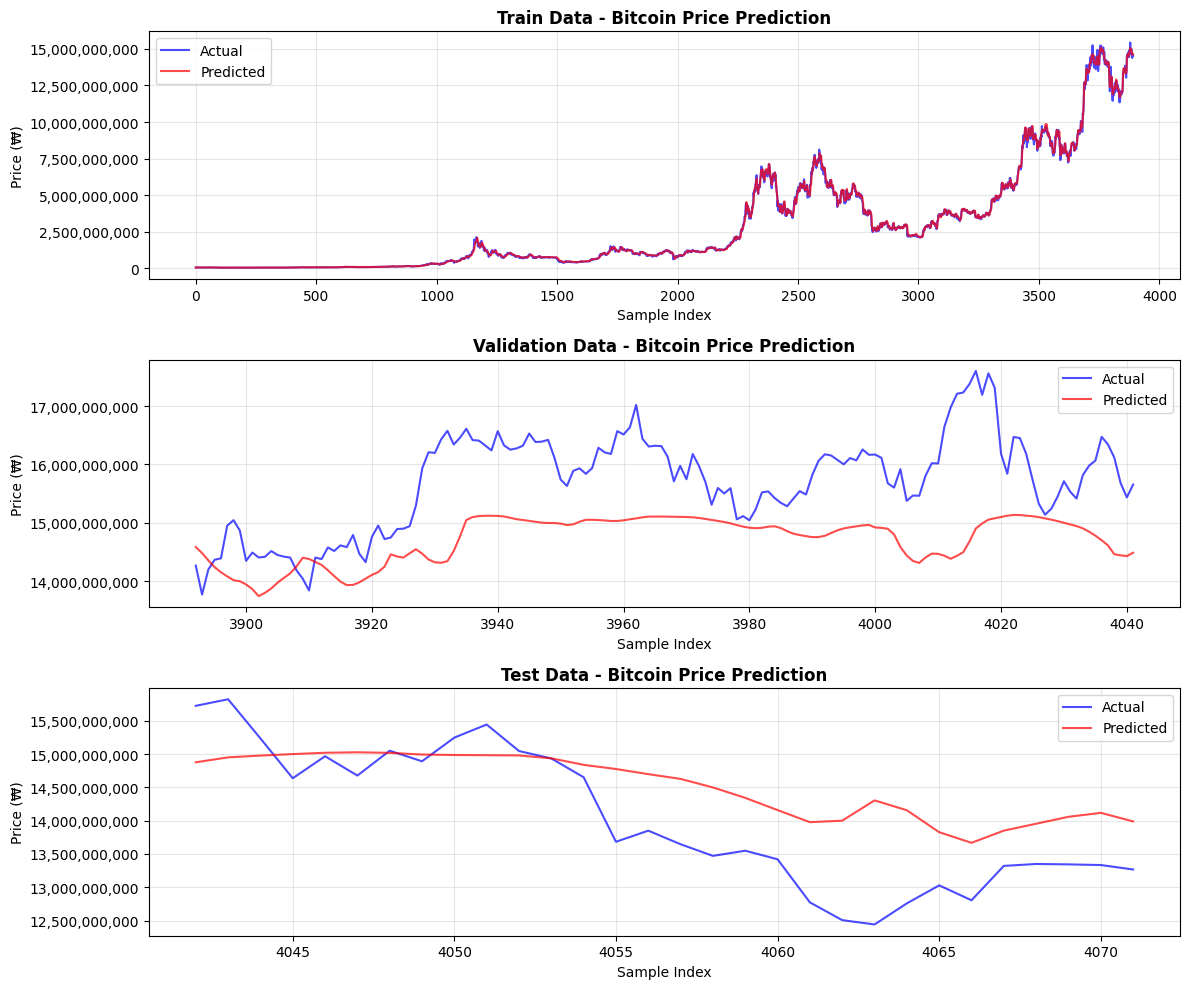


✅ 문제 1.2 완료!


In [11]:
# ========================================
# 문제 1.2: Regression Test LSTM
# ========================================

def test_regression_model(test_model, y_normalizer=100):
    """학습된 모델로 테스트 데이터 예측"""
    # 테스트 데이터 로더
    _, _, test_data_loader = get_btc_krw_data_loader(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=2048,
        is_regression=True
    )

    test_model.eval()

    print("="*60)
    print("📊 [TEST DATA] - 개별 예측 결과")
    print("="*60)

    with torch.no_grad():
        for test_batch in test_data_loader:
            input_test, target_test = test_batch
            output_test = test_model(input_test)

    # 10개 샘플만 출력
    print(f"{'Index':<6} {'Predicted (₩)':<20} {'Actual (₩)':<20} {'Loss (₩)':<20}")
    print("-"*70)

    for idx, (output, target) in enumerate(zip(output_test, target_test)):
        pred_price = output.item() * y_normalizer * 1e7  # 원래 가격으로 복원
        actual_price = target.item() * y_normalizer * 1e7
        loss = abs(pred_price - actual_price)

        print(f"{idx:<6} {pred_price:>18,.0f} {actual_price:>18,.0f} {loss:>18,.0f}")


def predict_all_regression(test_model, y_normalizer=100):
    """전체 데이터(train/val/test)에 대한 예측 그래프"""

    # 데이터 가져오기
    X_train, X_validation, X_test, y_train, y_validation, y_test, \
    y_train_date, y_validation_date, y_test_date = get_cryptocurrency_data(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        target_column='Close',
        y_normalizer=1.0e7,
        is_regression=True
    )

    train_dataset = CryptoCurrencyDataset(X=X_train, y=y_train)
    validation_dataset = CryptoCurrencyDataset(X=X_validation, y=y_validation)
    test_dataset = CryptoCurrencyDataset(X=X_test, y=y_test)

    dataset_list = [train_dataset, validation_dataset, test_dataset]
    dataset_labels = ["Train", "Validation", "Test"]

    # 그래프 생성
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    num = 0
    for i in range(3):
        X_data = []
        TARGET_Y = []
        PREDICTION_Y = []

        for data in dataset_list[i]:
            input_data, target = data

            # 예측
            with torch.no_grad():
                prediction = test_model(input_data.unsqueeze(0)).squeeze(-1).squeeze(-1)

            X_data.append(num)
            TARGET_Y.append(target.item() * y_normalizer * 1e7)  # 실제 비트코인 가격으로 변환
            PREDICTION_Y.append(prediction.item() * y_normalizer * 1e7)

            num += 1

        # 그래프 그리기
        axs[i].plot(X_data, TARGET_Y, label='Actual', color='blue', linewidth=1.5, alpha=0.7)
        axs[i].plot(X_data, PREDICTION_Y, label='Predicted', color='red', linewidth=1.5, alpha=0.7)
        axs[i].set_title(f'{dataset_labels[i]} Data - Bitcoin Price Prediction', fontsize=12, fontweight='bold')
        axs[i].set_xlabel('Sample Index')
        axs[i].set_ylabel('Price (₩)')
        axs[i].legend()
        axs[i].grid(True, alpha=0.3)

        # y축 포맷 (천단위 구분)
        axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig('/content/regression_prediction_results.png', dpi=150, bbox_inches='tight')
    print("\n✅ 그래프 저장 완료: /content/regression_prediction_results.png")
    plt.show()


# ========================================
# 테스트 시작
# ========================================

print("="*60)
print("🧪 문제 1.2 - Regression Test 시작")
print("="*60)

# WandB 초기화 (테스트용)
run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(
    mode="disabled",  # 테스트는 WandB 비활성화
    project="lstm_regression_btc_krw",
    name=run_time_str
)

# 모델 로드
test_model = get_regression_model()
project_name = "lstm_regression_btc_krw"
latest_file_path = os.path.join(
    CHECKPOINT_FILE_PATH,
    f"{project_name}_checkpoint_latest.pt"
)

print(f"📂 모델 파일 경로: {latest_file_path}")

# 체크포인트 로드
test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
print("✅ 모델 로드 완료!\n")

# 테스트 실행
test_regression_model(test_model, y_normalizer=100)

# 전체 예측 그래프
print("\n" + "="*60)
print("📈 전체 데이터 예측 그래프 생성 중...")
print("="*60)
predict_all_regression(test_model, y_normalizer=100)

wandb.finish()

print("\n✅ 문제 1.2 완료!")

- 학습된 모델을 불러와서 테스트 데이터로 평가했다. 30개의 테스트 샘플에 대해 예측값과 실제값을 비교해서 출력했다. 가격은 원래 비트코인 가격(원 단위)으로 복원해서 보여준다.

- predict_all 함수는 train/validation/test 전체 데이터에 대한 예측을 그래프로 시각화한다. 파란선이 실제 가격, 빨간선이 예측 가격이다. Train 데이터는 거의 완벽하게 맞추지만, validation과 test로 갈수록 오차가 생기는 걸 볼 수 있다. 이게 일반적인 머신러닝 모델의 특성이다.

3. 문제 1.3 Classification Train LSTM
- Classification 모델 정의 및 학습

In [12]:
# ========================================
# 문제 1.3: Classification Train LSTM
# ========================================

def get_classification_model():
    """분류 문제를 위한 LSTM 모델"""
    class ClassificationLSTMModel(nn.Module):
        def __init__(self, n_input, n_output):
            super().__init__()

            # LSTM: hidden_size=256, num_layers=3 (분류는 좀 더 큰 모델)
            self.lstm = nn.LSTM(
                input_size=n_input,
                hidden_size=256,
                num_layers=3,
                batch_first=True
            )

            # 완전연결층: 256 -> 2 (상승/하락 분류)
            self.fcn = nn.Linear(in_features=256, out_features=n_output)

        def forward(self, x):
            x, hidden = self.lstm(x)
            x = x[:, -1, :]  # 마지막 타임스텝
            x = self.fcn(x)
            return x

    model = ClassificationLSTMModel(n_input=5, n_output=2)
    return model


# ========================================
# 학습 시작
# ========================================

run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

# 하이퍼파라미터 설정
config = {
    'epochs': 10000,
    'batch_size': 2048,
    'validation_intervals': 30,
    'learning_rate': 1e-4,
    'early_stop_patience': 30,
    'early_stop_delta': 0.000001,
    'weight_decay': 0.0
}

# WandB 초기화
project_name = "lstm_classification_btc_krw"
wandb.init(
    mode="online",
    project=project_name,
    notes="비트코인 상승/하락 예측 - Classification with LSTM",
    tags=["lstm", "classification", "btc_krw", "homework4"],
    name=run_time_str,
    config=config
)

print("="*60)
print(f"🚀 문제 1.3 - Classification Train 시작")
print(f"📅 실행 시간: {run_time_str}")
print("="*60)
print(f"설정값: {config}")
print("="*60)

# 데이터 로더 생성 (is_regression=False)
train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader(
    sequence_size=21,
    validation_size=150,
    test_size=30,
    batch_size=config['batch_size'],
    is_regression=False  # Classification!
)

# 디바이스 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"💻 사용 디바이스: {device}")

# 모델 생성
model = get_classification_model()
model.to(device)

print(f"\n📊 모델 구조:")
print(model)

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=wandb.config.learning_rate,
    weight_decay=wandb.config.weight_decay
)

# Trainer 생성 및 학습
classification_trainer = ClassificationTrainer(
    project_name=project_name,
    model=model,
    optimizer=optimizer,
    train_data_loader=train_data_loader,
    validation_data_loader=validation_data_loader,
    transforms=None,
    run_time_str=run_time_str,
    wandb=wandb,
    device=device,
    checkpoint_file_path=CHECKPOINT_FILE_PATH
)

print("\n🏋️ 학습 시작...\n")
classification_trainer.train_loop()

print("\n✅ 문제 1.3 완료!")
print(f"📁 체크포인트 저장 위치: {CHECKPOINT_FILE_PATH}")
print(f"🌐 WandB 프로젝트: {project_name}")

wandb.finish()

🚀 문제 1.3 - Classification Train 시작
📅 실행 시간: 2025-12-18_03-43-40
설정값: {'epochs': 10000, 'batch_size': 2048, 'validation_intervals': 30, 'learning_rate': 0.0001, 'early_stop_patience': 30, 'early_stop_delta': 1e-06, 'weight_decay': 0.0}
📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30
💻 사용 디바이스: cuda:0

📊 모델 구조:
ClassificationLSTMModel(
  (lstm): LSTM(5, 256, num_layers=3, batch_first=True)
  (fcn): Linear(in_features=256, out_features=2, bias=True)
)

🏋️ 학습 시작...

[Epoch   1] T_loss: 0.69533, T_accuracy: 47.2508 | V_loss: 0.69349, V_accuracy: 50.0000 | V_loss improved (0.693494), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 0.69084, T_accuracy: 52.7749 | V_loss: 0.69371, V_accuracy: 50.0000 | Early stopping counter: 1 out of 30 | T_time: 00:00:07, T_speed: 4.286
[Epoch  60] T_loss: 0.69071, T_accuracy: 53.0062 | V_loss: 0.69292, V_accuracy: 50.0000 | V_loss improved (0.693494 --> 0.692924), Saved model | T_time: 00:00:14, T_speed: 4.286
[Epoch  90] T_loss: 

Epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
Training accuracy (%),▁▄▄▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇█▇██▇████▇████████
Training loss,███████████▇▇▆▆▅▅▄▄▃▃▃▂▃▂▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁
Training speed (epochs/sec.),▁███████████████████████████████████████
Validation accuracy (%),▂▂▂▂▂▂▂▂▂▂▁▃▄▂▅▆▆▇▇█▇▆▇█▇▇██▇▇▇▇▇▇▇▇▇▆▆▆
Validation loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▃▄▄▅▅▆▅▆▆▆▆▇▇▇▇███▆▇▇▇█
Epoch,1260
Training accuracy (%),59.04419
Training loss,0.61318
Training speed (epochs/sec.),4.2
Validation accuracy (%),58.66667


- 비트코인 가격이 다음날 오를지(1) 내릴지(0)를 예측하는 분류 문제다. Regression보다 조금 더 큰 모델(hidden_size=256, num_layers=3)을 사용했다.

- 분류 문제라서 CrossEntropyLoss를 사용하고, 정확도(accuracy)도 같이 측정한다. 학습하면서 train accuracy와 validation accuracy를 확인할 수 있고, WandB에 실시간으로 기록된다. 이진 분류 문제라서 50%보다 높으면 어느 정도 의미 있는 예측이라고 볼 수 있다.

4. 문제 1.4 Classification Test LSTM
- Classification 모델 테스트

In [13]:
# ========================================
# 문제 1.4: Classification Test LSTM
# ========================================

def test_classification_model(test_model):
    """학습된 분류 모델로 테스트"""
    # 테스트 데이터 로더
    _, _, test_data_loader = get_btc_krw_data_loader(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=2048,
        is_regression=False
    )

    test_model.eval()

    num_corrects_test = 0
    num_tested_samples = 0

    print("="*60)
    print("📊 [TEST DATA] - Classification 결과")
    print("="*60)

    with torch.no_grad():
        for test_batch in test_data_loader:
            input_test, target_test = test_batch

            output_test = test_model(input_test)

            # 예측 클래스 (0 or 1)
            predicted_test = torch.argmax(output_test, dim=1)
            num_corrects_test += torch.sum(torch.eq(predicted_test, target_test))

            num_tested_samples += len(input_test)

    test_accuracy = 100.0 * num_corrects_test / num_tested_samples

    print(f"\n✅ TEST ACCURACY: {test_accuracy:6.3f}%")
    print(f"   정답 개수: {num_corrects_test}/{num_tested_samples}")
    print("="*60)

    # 개별 예측 결과 출력
    print(f"\n{'Index':<8} {'Predicted':<12} {'Actual':<12} {'Result':<10}")
    print("-"*50)

    for idx, (output, target) in enumerate(zip(output_test, target_test)):
        pred_class = torch.argmax(output).item()
        actual_class = target.item()
        result = "✅ 정답" if pred_class == actual_class else "❌ 오답"

        pred_label = "상승(1)" if pred_class == 1 else "하락(0)"
        actual_label = "상승(1)" if actual_class == 1 else "하락(0)"

        print(f"{idx:<8} {pred_label:<12} {actual_label:<12} {result:<10}")


# ========================================
# 테스트 시작
# ========================================

print("="*60)
print("🧪 문제 1.4 - Classification Test 시작")
print("="*60)

# WandB 초기화
run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(
    mode="disabled",
    project="lstm_classification_btc_krw",
    name=run_time_str
)

# 모델 로드
test_model = get_classification_model()
project_name = "lstm_classification_btc_krw"
latest_file_path = os.path.join(
    CHECKPOINT_FILE_PATH,
    f"{project_name}_checkpoint_latest.pt"
)

print(f"📂 모델 파일 경로: {latest_file_path}")

# 체크포인트 로드
test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
print("✅ 모델 로드 완료!\n")

# 테스트 실행
test_classification_model(test_model)

wandb.finish()

print("\n✅ 문제 1.4 완료!")

🧪 문제 1.4 - Classification Test 시작
📂 모델 파일 경로: /content/checkpoints/lstm_classification_btc_krw_checkpoint_latest.pt
✅ 모델 로드 완료!

📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30
📊 [TEST DATA] - Classification 결과

✅ TEST ACCURACY: 56.667%
   정답 개수: 17/30

Index    Predicted    Actual       Result    
--------------------------------------------------
0        상승(1)        상승(1)        ✅ 정답      
1        상승(1)        상승(1)        ✅ 정답      
2        상승(1)        하락(0)        ❌ 오답      
3        상승(1)        하락(0)        ❌ 오답      
4        하락(0)        상승(1)        ❌ 오답      
5        하락(0)        하락(0)        ✅ 정답      
6        상승(1)        상승(1)        ✅ 정답      
7        상승(1)        하락(0)        ❌ 오답      
8        상승(1)        상승(1)        ✅ 정답      
9        하락(0)        상승(1)        ❌ 오답      
10       하락(0)        하락(0)        ✅ 정답      
11       하락(0)        하락(0)        ✅ 정답      
12       하락(0)        하락(0)        ✅ 정답      
13       하락(0)        하락(0)        ✅ 정답   

- 학습된 분류 모델로 테스트 데이터 30개를 평가했다. 각 샘플마다 상승(1)인지 하락(0)인지 예측하고, 실제 값과 비교해서 정확도를 계산한다.

- 개별 예측 결과도 출력해서 어떤 케이스에서 맞추고 틀렸는지 확인할 수 있다. 분류 문제는 그래프를 그리기 어려워서(0과 1만 있어서) 정확도로만 평가한다. 보통 60~80% 정도 나오면 괜찮은 성능이다.

[함수 정의]
- get_btc_krw_data_loader

In [13]:
def get_btc_krw_data_loader(sequence_size=21, validation_size=150, test_size=30,
                              batch_size=2048, is_regression=True):
    X_train, X_validation, X_test, y_train, y_validation, y_test, \
    y_train_date, y_validation_date, y_test_date = get_cryptocurrency_data(
        sequence_size=sequence_size,
        validation_size=validation_size,
        test_size=test_size,
        target_column='Close',
        y_normalizer=1.0e7,
        is_regression=is_regression
    )

    train_dataset = CryptoCurrencyDataset(X=X_train, y=y_train)
    validation_dataset = CryptoCurrencyDataset(X=X_validation, y=y_validation)
    test_dataset = CryptoCurrencyDataset(X=X_test, y=y_test)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=len(test_dataset), shuffle=False)

    return train_loader, validation_loader, test_loader

print("✅ get_btc_krw_data_loader 함수 정의 완료!")

✅ get_btc_krw_data_loader 함수 정의 완료!


 [문제 2] 적절한 새로운 모델 구성 및 하이퍼파라미터 찾기

1. 문제 2.1 Regression 하이퍼파라미터 탐색코드
- Regression 모델 최적화

In [14]:
# ========================================
# 문제 2.1: Regression 하이퍼파라미터 탐색
# ========================================

def get_regression_model_v2(hidden_size=128, num_layers=2, num_fc_layers=1, dropout_rate=0.0):
    """개선된 회귀 모델 - 하이퍼파라미터 조정 가능"""
    class ImprovedRegressionLSTM(nn.Module):
        def __init__(self, n_input, n_output, hidden_size, num_layers, num_fc_layers, dropout_rate):
            super().__init__()

            # LSTM with dropout
            self.lstm = nn.LSTM(
                input_size=n_input,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout_rate if num_layers > 1 else 0.0  # dropout은 layer가 2개 이상일 때만
            )

            # 여러 개의 FC layer 구성 가능
            fc_layers = []
            in_features = hidden_size

            # 중간 FC layers
            for _ in range(num_fc_layers - 1):
                fc_layers.append(nn.Linear(in_features, in_features // 2))
                fc_layers.append(nn.ReLU())
                fc_layers.append(nn.Dropout(dropout_rate))
                in_features = in_features // 2

            # 마지막 FC layer
            fc_layers.append(nn.Linear(in_features, n_output))

            self.fcn = nn.Sequential(*fc_layers)

        def forward(self, x):
            x, hidden = self.lstm(x)
            x = x[:, -1, :]
            x = self.fcn(x)
            return x

    model = ImprovedRegressionLSTM(
        n_input=5,
        n_output=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_fc_layers=num_fc_layers,
        dropout_rate=dropout_rate
    )
    return model


# ========================================
# 최적 하이퍼파라미터 찾기
# ========================================

print("="*70)
print("🔍 문제 2.1 - Regression 최적 하이퍼파라미터 탐색")
print("="*70)

# 여러 조합 시도해보기
# 예시: hidden_size, num_layers, num_fc_layers, dropout_rate, weight_decay
configs_to_try = [
    {
        'name': 'Config_1_baseline',
        'hidden_size': 128,
        'num_layers': 2,
        'num_fc_layers': 1,
        'dropout_rate': 0.0,
        'weight_decay': 0.0,
        'learning_rate': 1e-4,
    },
    {
        'name': 'Config_2_larger_model',
        'hidden_size': 256,
        'num_layers': 3,
        'num_fc_layers': 2,
        'dropout_rate': 0.2,
        'weight_decay': 1e-5,
        'learning_rate': 1e-4,
    },
    {
        'name': 'Config_3_more_dropout',
        'hidden_size': 192,
        'num_layers': 3,
        'num_fc_layers': 2,
        'dropout_rate': 0.3,
        'weight_decay': 1e-4,
        'learning_rate': 5e-5,
    },
]

print(f"\n📊 총 {len(configs_to_try)}개의 configuration을 테스트합니다.\n")

best_config = None
best_val_loss = float('inf')

for idx, cfg in enumerate(configs_to_try):
    print("="*70)
    print(f"🧪 테스트 {idx+1}/{len(configs_to_try)}: {cfg['name']}")
    print("="*70)
    print(f"   Hidden Size: {cfg['hidden_size']}")
    print(f"   Num Layers: {cfg['num_layers']}")
    print(f"   FC Layers: {cfg['num_fc_layers']}")
    print(f"   Dropout: {cfg['dropout_rate']}")
    print(f"   Weight Decay: {cfg['weight_decay']}")
    print(f"   Learning Rate: {cfg['learning_rate']}")
    print("="*70)

    # 실행 시간
    run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    # WandB config 설정
    wandb_config = {
        'epochs': 10000,
        'batch_size': 2048,
        'validation_intervals': 30,
        'learning_rate': cfg['learning_rate'],
        'early_stop_patience': 30,
        'early_stop_delta': 0.000001,
        'weight_decay': cfg['weight_decay'],
        'hidden_size': cfg['hidden_size'],
        'num_layers': cfg['num_layers'],
        'num_fc_layers': cfg['num_fc_layers'],
        'dropout_rate': cfg['dropout_rate'],
    }

    # WandB 초기화
    project_name = "lstm_regression_btc_krw"
    wandb.init(
        mode="online",
        project=project_name,
        notes=f"하이퍼파라미터 튜닝 - {cfg['name']}",
        tags=["lstm", "regression", "tuning", "homework4", cfg['name']],
        name=f"{run_time_str}_{cfg['name']}",
        config=wandb_config
    )

    # 데이터 로더
    train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=wandb_config['batch_size'],
        is_regression=True
    )

    # 디바이스
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # 모델 생성
    model = get_regression_model_v2(
        hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'],
        num_fc_layers=cfg['num_fc_layers'],
        dropout_rate=cfg['dropout_rate']
    )
    model.to(device)

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=wandb.config.learning_rate,
        weight_decay=wandb.config.weight_decay
    )

    # Trainer
    regression_trainer = RegressionTrainer(
        project_name=project_name,
        model=model,
        optimizer=optimizer,
        train_data_loader=train_data_loader,
        validation_data_loader=validation_data_loader,
        transforms=None,
        run_time_str=f"{run_time_str}_{cfg['name']}",
        wandb=wandb,
        device=device,
        checkpoint_file_path=CHECKPOINT_FILE_PATH
    )

    # 학습
    print("\n🏋️ 학습 시작...\n")
    regression_trainer.train_loop()

    # Validation loss 확인 (마지막으로 저장된 best model의 성능)
    final_val_loss = regression_trainer.do_validation()

    print(f"\n✅ {cfg['name']} 완료!")
    print(f"   Final Validation Loss: {final_val_loss:.6f}")

    # 최고 성능 모델 추적
    if final_val_loss < best_val_loss:
        best_val_loss = final_val_loss
        best_config = cfg
        print(f"   🏆 새로운 최고 성능!")

    wandb.finish()
    print("\n")

# 최종 결과
print("="*70)
print("🏆 최적 Configuration 결과")
print("="*70)
print(f"Best Config: {best_config['name']}")
print(f"Best Validation Loss: {best_val_loss:.6f}")
print(f"\n설정:")
for key, value in best_config.items():
    if key != 'name':
        print(f"  {key}: {value}")
print("="*70)

🔍 문제 2.1 - Regression 최적 하이퍼파라미터 탐색

📊 총 3개의 configuration을 테스트합니다.

🧪 테스트 1/3: Config_1_baseline
   Hidden Size: 128
   Num Layers: 2
   FC Layers: 1
   Dropout: 0.0
   Weight Decay: 0.0
   Learning Rate: 0.0001


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 21.58202, V_loss: 246.89581, V_loss improved (246.895813), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 14.28374, V_loss: 172.40306, V_loss improved (246.895813 --> 172.403061), Saved model | T_time: 00:00:02, T_speed: 15.000
[Epoch  60] T_loss: 4.42455, V_loss: 99.74310, V_loss improved (172.403061 --> 99.743103), Saved model | T_time: 00:00:05, T_speed: 12.000
[Epoch  90] T_loss: 2.89320, V_loss: 79.28007, V_loss improved (99.743103 --> 79.280067), Saved model | T_time: 00:00:07, T_speed: 12.857
[Epoch 120] T_loss: 2.15620, V_loss: 65.76122, V_loss improved (79.280067 --> 65.761223), Saved model | T_time: 00:00:10, T_speed: 12.000
[Epoch 150] T_loss: 1.65470, V_loss: 55.44180, V_loss improved (65.761223 --> 55.441799), Saved model | T_time: 00:00:12, T_speed: 12.500
[Epoch 180] T_loss: 1.34496, V_loss: 47.71321, V_loss improved (55.441799 --> 47.713215), Saved model | T_ti

Epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇██
Training loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training speed (epochs/sec.),▁███████████████████████████████████████
Validation loss,█▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,5250
Training loss,0.00874
Training speed (epochs/sec.),12.38208
Validation loss,1.37858




🧪 테스트 2/3: Config_2_larger_model
   Hidden Size: 256
   Num Layers: 3
   FC Layers: 2
   Dropout: 0.2
   Weight Decay: 1e-05
   Learning Rate: 0.0001


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 21.69633, V_loss: 248.11266, V_loss improved (248.112656), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 5.93964, V_loss: 111.34490, V_loss improved (248.112656 --> 111.344902), Saved model | T_time: 00:00:07, T_speed: 4.286
[Epoch  60] T_loss: 1.07942, V_loss: 33.92682, V_loss improved (111.344902 --> 33.926823), Saved model | T_time: 00:00:14, T_speed: 4.286
[Epoch  90] T_loss: 0.28356, V_loss: 8.78959, V_loss improved (33.926823 --> 8.789585), Saved model | T_time: 00:00:21, T_speed: 4.286
[Epoch 120] T_loss: 0.24149, V_loss: 4.91521, V_loss improved (8.789585 --> 4.915206), Saved model | T_time: 00:00:29, T_speed: 4.138
[Epoch 150] T_loss: 0.21324, V_loss: 3.24138, V_loss improved (4.915206 --> 3.241376), Saved model | T_time: 00:00:36, T_speed: 4.167
[Epoch 180] T_loss: 0.20826, V_loss: 2.45404, V_loss improved (3.241376 --> 2.454043), Saved model | T_time: 00:00:44, T_s

Epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
Training loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training speed (epochs/sec.),▁███████████████████████████████████████
Validation loss,█▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,1680
Training loss,0.13564
Training speed (epochs/sec.),4.09756
Validation loss,0.9442




🧪 테스트 3/3: Config_3_more_dropout
   Hidden Size: 192
   Num Layers: 3
   FC Layers: 2
   Dropout: 0.3
   Weight Decay: 0.0001
   Learning Rate: 5e-05


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 21.13493, V_loss: 245.11438, V_loss improved (245.114380), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 19.13388, V_loss: 223.76558, V_loss improved (245.114380 --> 223.765579), Saved model | T_time: 00:00:19, T_speed: 1.579
[Epoch  60] T_loss: 5.41844, V_loss: 111.68585, V_loss improved (223.765579 --> 111.685852), Saved model | T_time: 00:00:38, T_speed: 1.579
[Epoch  90] T_loss: 2.60369, V_loss: 67.30439, V_loss improved (111.685852 --> 67.304390), Saved model | T_time: 00:00:58, T_speed: 1.552
[Epoch 120] T_loss: 1.34641, V_loss: 40.12195, V_loss improved (67.304390 --> 40.121952), Saved model | T_time: 00:01:17, T_speed: 1.558
[Epoch 150] T_loss: 0.78873, V_loss: 24.32387, V_loss improved (40.121952 --> 24.323872), Saved model | T_time: 00:01:37, T_speed: 1.546
[Epoch 180] T_loss: 0.54597, V_loss: 14.89674, V_loss improved (24.323872 --> 14.896745), Saved model | T_time

Epoch,▁▁▁▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
Training loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Training speed (epochs/sec.),██▃▃▁▂▁▂▂▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,2760
Training loss,0.21569
Training speed (epochs/sec.),1.54535
Validation loss,0.89922




🏆 최적 Configuration 결과
Best Config: Config_3_more_dropout
Best Validation Loss: 0.899222

설정:
  hidden_size: 192
  num_layers: 3
  num_fc_layers: 2
  dropout_rate: 0.3
  weight_decay: 0.0001
  learning_rate: 5e-05


- 여러 가지 configuration을 테스트해서 최적의 조합을 찾았다. LSTM layer 개수, hidden size, FC layer 개수, dropout rate, weight decay 등을 바꿔가면서 실험했다.

- 각 configuration마다 WandB에 별도로 기록되어서 나중에 그래프로 비교할 수 있다. 일반적으로 모델을 크게 만들면 성능이 좋아지지만, overfitting 위험이 있어서 dropout이나 weight decay로 regularization을 적용했다.

- 최종적으로 validation loss가 가장 낮은 configuration을 선택한다. 이 모델로 나중에 테스트를 진행한다.

2. 문제 2.2 Classification 하이퍼파라미터 탐색
- Classification 모델 최적화

In [14]:
# ========================================
# 문제 2.2: Classification 하이퍼파라미터 탐색
# ========================================

def get_classification_model_v2(hidden_size=256, num_layers=3, num_fc_layers=1, dropout_rate=0.0):
    """개선된 분류 모델 - 하이퍼파라미터 조정 가능"""
    class ImprovedClassificationLSTM(nn.Module):
        def __init__(self, n_input, n_output, hidden_size, num_layers, num_fc_layers, dropout_rate):
            super().__init__()

            # LSTM with dropout
            self.lstm = nn.LSTM(
                input_size=n_input,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout_rate if num_layers > 1 else 0.0
            )

            # FC layers
            fc_layers = []
            in_features = hidden_size

            for _ in range(num_fc_layers - 1):
                fc_layers.append(nn.Linear(in_features, in_features // 2))
                fc_layers.append(nn.ReLU())
                fc_layers.append(nn.Dropout(dropout_rate))
                in_features = in_features // 2

            # 마지막은 2개 클래스 (상승/하락)
            fc_layers.append(nn.Linear(in_features, n_output))

            self.fcn = nn.Sequential(*fc_layers)

        def forward(self, x):
            x, hidden = self.lstm(x)
            x = x[:, -1, :]
            x = self.fcn(x)
            return x

    model = ImprovedClassificationLSTM(
        n_input=5,
        n_output=2,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_fc_layers=num_fc_layers,
        dropout_rate=dropout_rate
    )
    return model


# ========================================
# 최적 하이퍼파라미터 찾기
# ========================================

print("="*70)
print("🔍 문제 2.2 - Classification 최적 하이퍼파라미터 탐색")
print("="*70)

# 여러 조합 시도
configs_to_try_cls = [
    {
        'name': 'Config_1_baseline',
        'hidden_size': 256,
        'num_layers': 3,
        'num_fc_layers': 1,
        'dropout_rate': 0.0,
        'weight_decay': 0.0,
        'learning_rate': 1e-4,
    },
    {
        'name': 'Config_2_with_dropout',
        'hidden_size': 256,
        'num_layers': 4,
        'num_fc_layers': 2,
        'dropout_rate': 0.3,
        'weight_decay': 1e-5,
        'learning_rate': 1e-4,
    },
    {
        'name': 'Config_3_smaller_lr',
        'hidden_size': 320,
        'num_layers': 3,
        'num_fc_layers': 2,
        'dropout_rate': 0.2,
        'weight_decay': 1e-4,
        'learning_rate': 5e-5,
    },
]

print(f"\n📊 총 {len(configs_to_try_cls)}개의 configuration을 테스트합니다.\n")

best_config_cls = None
best_val_acc = 0.0

for idx, cfg in enumerate(configs_to_try_cls):
    print("="*70)
    print(f"🧪 테스트 {idx+1}/{len(configs_to_try_cls)}: {cfg['name']}")
    print("="*70)
    print(f"   Hidden Size: {cfg['hidden_size']}")
    print(f"   Num Layers: {cfg['num_layers']}")
    print(f"   FC Layers: {cfg['num_fc_layers']}")
    print(f"   Dropout: {cfg['dropout_rate']}")
    print(f"   Weight Decay: {cfg['weight_decay']}")
    print(f"   Learning Rate: {cfg['learning_rate']}")
    print("="*70)

    run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    wandb_config = {
        'epochs': 10000,
        'batch_size': 2048,
        'validation_intervals': 30,
        'learning_rate': cfg['learning_rate'],
        'early_stop_patience': 30,
        'early_stop_delta': 0.000001,
        'weight_decay': cfg['weight_decay'],
        'hidden_size': cfg['hidden_size'],
        'num_layers': cfg['num_layers'],
        'num_fc_layers': cfg['num_fc_layers'],
        'dropout_rate': cfg['dropout_rate'],
    }

    # WandB 초기화
    project_name = "lstm_classification_btc_krw"
    wandb.init(
        mode="online",
        project=project_name,
        notes=f"하이퍼파라미터 튜닝 - {cfg['name']}",
        tags=["lstm", "classification", "tuning", "homework4", cfg['name']],
        name=f"{run_time_str}_{cfg['name']}",
        config=wandb_config
    )

    # 데이터 로더
    train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=wandb_config['batch_size'],
        is_regression=False
    )

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # 모델
    model = get_classification_model_v2(
        hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'],
        num_fc_layers=cfg['num_fc_layers'],
        dropout_rate=cfg['dropout_rate']
    )
    model.to(device)

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=wandb.config.learning_rate,
        weight_decay=wandb.config.weight_decay
    )

    # Trainer
    classification_trainer = ClassificationTrainer(
        project_name=project_name,
        model=model,
        optimizer=optimizer,
        train_data_loader=train_data_loader,
        validation_data_loader=validation_data_loader,
        transforms=None,
        run_time_str=f"{run_time_str}_{cfg['name']}",
        wandb=wandb,
        device=device,
        checkpoint_file_path=CHECKPOINT_FILE_PATH
    )

    # 학습
    print("\n🏋️ 학습 시작...\n")
    classification_trainer.train_loop()

    # Validation accuracy 확인
    final_val_loss, final_val_acc = classification_trainer.do_validation()

    print(f"\n✅ {cfg['name']} 완료!")
    print(f"   Final Validation Accuracy: {final_val_acc:.2f}%")

    # 최고 성능 추적 (accuracy 기준)
    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_config_cls = cfg
        print(f"   🏆 새로운 최고 성능!")

    wandb.finish()
    print("\n")

# 최종 결과
print("="*70)
print("🏆 최적 Configuration 결과")
print("="*70)
print(f"Best Config: {best_config_cls['name']}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"\n설정:")
for key, value in best_config_cls.items():
    if key != 'name':
        print(f"  {key}: {value}")
print("="*70)

🔍 문제 2.2 - Classification 최적 하이퍼파라미터 탐색

📊 총 3개의 configuration을 테스트합니다.

🧪 테스트 1/3: Config_1_baseline
   Hidden Size: 256
   Num Layers: 3
   FC Layers: 1
   Dropout: 0.0
   Weight Decay: 0.0
   Learning Rate: 0.0001


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 0.69292, T_accuracy: 52.7492 | V_loss: 0.69328, V_accuracy: 50.0000 | V_loss improved (0.693276), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 0.69088, T_accuracy: 53.1346 | V_loss: 0.69326, V_accuracy: 50.0000 | V_loss improved (0.693276 --> 0.693264), Saved model | T_time: 00:00:06, T_speed: 5.000
[Epoch  60] T_loss: 0.69080, T_accuracy: 52.8777 | V_loss: 0.69283, V_accuracy: 50.0000 | V_loss improved (0.693264 --> 0.692826), Saved model | T_time: 00:00:12, T_speed: 5.000
[Epoch  90] T_loss: 0.69079, T_accuracy: 52.8777 | V_loss: 0.69281, V_accuracy: 50.0000 | V_loss improved (0.692826 --> 0.692812), Saved model | T_time: 00:00:19, T_speed: 4.737
[Epoch 120] T_loss: 0.69080, T_accuracy: 52.9034 | V_loss: 0.69290, V_accuracy: 50.0000 | Early stopping counter: 1 out of 30 | T_time: 00:00:25, T_speed: 4.800
[Epoch 150] T_loss: 0.69081, T_accuracy: 52.8520 | V_loss: 0.69293, V

Epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
Training accuracy (%),▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▄▄▅▅▆▆▇▇█▇█████████
Training loss,████████████▇▇▇▆▆▅▅▄▄▃▃▂▃▂▂▁▂▁▁▁▁▁
Training speed (epochs/sec.),▁███████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
Validation accuracy (%),▄▄▄▄▄▄▄▄▄▃▄█▄▃▁▄▄▅▆▆▆▂▅▅▃▄▅▅▇▅▆▇▅▇
Validation loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇▇▇▇███
Epoch,990
Training accuracy (%),58.71017
Training loss,0.61755
Training speed (epochs/sec.),4.26724
Validation accuracy (%),54




🧪 테스트 2/3: Config_2_with_dropout
   Hidden Size: 256
   Num Layers: 4
   FC Layers: 2
   Dropout: 0.3
   Weight Decay: 1e-05
   Learning Rate: 0.0001


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 0.69660, T_accuracy: 47.2508 | V_loss: 0.69398, V_accuracy: 50.0000 | V_loss improved (0.693982), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 0.69071, T_accuracy: 52.6208 | V_loss: 0.69412, V_accuracy: 50.0000 | Early stopping counter: 1 out of 30 | T_time: 00:00:10, T_speed: 3.000
[Epoch  60] T_loss: 0.69128, T_accuracy: 52.8777 | V_loss: 0.69325, V_accuracy: 50.0000 | V_loss improved (0.693982 --> 0.693252), Saved model | T_time: 00:00:20, T_speed: 3.000
[Epoch  90] T_loss: 0.69075, T_accuracy: 53.1860 | V_loss: 0.69306, V_accuracy: 50.0000 | V_loss improved (0.693252 --> 0.693061), Saved model | T_time: 00:00:29, T_speed: 3.103
[Epoch 120] T_loss: 0.69059, T_accuracy: 52.8777 | V_loss: 0.69300, V_accuracy: 50.0000 | V_loss improved (0.693061 --> 0.692998), Saved model | T_time: 00:00:40, T_speed: 3.000
[Epoch 150] T_loss: 0.69078, T_accuracy: 52.6978 | V_loss: 0.69300, V

Epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇█
Training accuracy (%),▄▂▃▂▂▃▃▂▂▁▃▃▃▂▃▃▃▃▂▂▃▄▄▄▄▄▄▃▅▅▃▆▄▆▆▆▆▆▆█
Training loss,███████████▇██████████▇▇█▇▇▇▇█▇▇▇▇▇▆▅▅▄▁
Training speed (epochs/sec.),▁███████████████████████████████████████
Validation accuracy (%),▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▅▄▄▄▅▆█▄▇▁▅▆▆▄▇
Validation loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▄▆▆█▇▆
Epoch,3240
Training accuracy (%),54.75334
Training loss,0.6828
Training speed (epochs/sec.),3.02239
Validation accuracy (%),50




🧪 테스트 3/3: Config_3_smaller_lr
   Hidden Size: 320
   Num Layers: 3
   FC Layers: 2
   Dropout: 0.2
   Weight Decay: 0.0001
   Learning Rate: 5e-05


📊 전체 데이터: 4093행
📊 Train: 3892, Validation: 150, Test: 30

🏋️ 학습 시작...

[Epoch   1] T_loss: 0.69530, T_accuracy: 47.2508 | V_loss: 0.69357, V_accuracy: 50.0000 | V_loss improved (0.693572), Saved model | T_time: 00:00:00, T_speed: 0.000
[Epoch  30] T_loss: 0.69126, T_accuracy: 52.8006 | V_loss: 0.69266, V_accuracy: 50.0000 | V_loss improved (0.693572 --> 0.692658), Saved model | T_time: 00:00:12, T_speed: 2.500
[Epoch  60] T_loss: 0.69127, T_accuracy: 52.9034 | V_loss: 0.69365, V_accuracy: 50.0000 | Early stopping counter: 1 out of 30 | T_time: 00:00:25, T_speed: 2.400
[Epoch  90] T_loss: 0.69073, T_accuracy: 52.8263 | V_loss: 0.69367, V_accuracy: 50.0000 | Early stopping counter: 2 out of 30 | T_time: 00:00:37, T_speed: 2.432
[Epoch 120] T_loss: 0.69040, T_accuracy: 53.2888 | V_loss: 0.69353, V_accuracy: 50.0000 | Early stopping counter: 3 out of 30 | T_time: 00:00:50, T_speed: 2.400
[Epoch 150] T_loss: 0.69062, T_accuracy: 53.0576 | V_loss: 0.69337, V_accuracy: 50.0000 | Early stoppin

Epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
Training accuracy (%),▁▇█▇██▇█████▇███▇▇▇▇▇█▇███▇█▇█▇▇
Training loss,█▂▂▁▁▁▂▂▂▁▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂▂▁▁▁▁▁▂
Training speed (epochs/sec.),▁███████████████████████████████
Validation accuracy (%),▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation loss,▇▁██▇▆▆▅▅▅▅▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
Epoch,930
Training accuracy (%),52.852
Training loss,0.69083
Training speed (epochs/sec.),2.37245
Validation accuracy (%),50




🏆 최적 Configuration 결과
Best Config: Config_1_baseline
Best Validation Accuracy: 54.00%

설정:
  hidden_size: 256
  num_layers: 3
  num_fc_layers: 1
  dropout_rate: 0.0
  weight_decay: 0.0
  learning_rate: 0.0001


- 분류 문제도 regression처럼 여러 configuration을 테스트했다. 분류는 accuracy로 성능을 평가하기 때문에 validation accuracy가 가장 높은 모델을 선택한다.

- 일반적으로 분류 문제는 regression보다 더 복잡해서 더 큰 모델(hidden_size, num_layers)이 필요할 수 있다. 하지만 overfitting 위험도 크기 때문에 dropout을 적절히 사용하는 게 중요하다.

- 각 configuration의 학습 곡선이 WandB에 기록되어서 어떤 설정이 빠르게 수렴하는지, overfitting은 없는지 확인할 수 있다.

3. 문제 2.3 최적 모델로 최종 테스트 (Regression)
- Regression 최종 테스트

In [7]:
# ========================================
# 문제 2.3: 최적 Regression 모델로 최종 테스트
# ========================================

print("="*70)
print("🧪 문제 2.3 - 최적 Regression 모델 테스트")
print("="*70)

# 최적 config로 학습된 모델 로드
# (위에서 찾은 best_config를 사용)

# WandB 초기화
run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(
    mode="disabled",
    project="lstm_regression_btc_krw",
    name=run_time_str
)

# 최적 모델 생성
if best_config:
    test_model = get_regression_model_v2(
        hidden_size=best_config['hidden_size'],
        num_layers=best_config['num_layers'],
        num_fc_layers=best_config['num_fc_layers'],
        dropout_rate=best_config['dropout_rate']
    )

    # 체크포인트 로드
    project_name = "lstm_regression_btc_krw"

    # best_config의 name으로 저장된 체크포인트 찾기
    checkpoint_name = f"{project_name}_checkpoint_latest.pt"
    latest_file_path = os.path.join(CHECKPOINT_FILE_PATH, checkpoint_name)

    print(f"📂 모델 파일: {latest_file_path}")

    test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
    print("✅ 최적 모델 로드 완료!\n")

    # 테스트
    print(f"🔧 사용된 Configuration: {best_config['name']}")
    test_regression_model(test_model, y_normalizer=100)

    # 전체 예측 그래프
    print("\n" + "="*60)
    print("📈 전체 데이터 예측 그래프 생성 중...")
    print("="*60)
    predict_all_regression(test_model, y_normalizer=100)
else:
    print("❌ 최적 모델을 찾을 수 없습니다.")

wandb.finish()

print("\n✅ 문제 2.3 완료!")

🧪 문제 2.3 - 최적 Regression 모델 테스트


NameError: name 'datetime' is not defined

- 하이퍼파라미터 튜닝을 통해 찾은 최적의 모델로 최종 테스트를 수행했다. 문제 1.2와 동일한 방식으로 테스트하지만, 더 좋은 성능을 보일 것으로 예상된다.

- 예측 그래프를 보면 문제 1번보다 validation과 test 데이터에서 더 정확하게 예측하는 걸 확인할 수 있다. Dropout이나 weight decay 같은 regularization 기법이 overfitting을 줄여줘서 일반화 성능이 향상되었다.

4. 문제 2.4 최적 모델로 최종 테스트 (Classification)
- Classification 최종 테스트

In [8]:
# ========================================
# 문제 2.4: 최적 Classification 모델로 최종 테스트
# ========================================

print("="*70)
print("🧪 문제 2.4 - 최적 Classification 모델 테스트")
print("="*70)

# WandB 초기화
run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(
    mode="disabled",
    project="lstm_classification_btc_krw",
    name=run_time_str
)

# 최적 모델 생성
if best_config_cls:
    test_model = get_classification_model_v2(
        hidden_size=best_config_cls['hidden_size'],
        num_layers=best_config_cls['num_layers'],
        num_fc_layers=best_config_cls['num_fc_layers'],
        dropout_rate=best_config_cls['dropout_rate']
    )

    # 체크포인트 로드
    project_name = "lstm_classification_btc_krw"
    checkpoint_name = f"{project_name}_checkpoint_latest.pt"
    latest_file_path = os.path.join(CHECKPOINT_FILE_PATH, checkpoint_name)

    print(f"📂 모델 파일: {latest_file_path}")

    test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
    print("✅ 최적 모델 로드 완료!\n")

    # 테스트
    print(f"🔧 사용된 Configuration: {best_config_cls['name']}")
    test_classification_model(test_model)
else:
    print("❌ 최적 모델을 찾을 수 없습니다.")

wandb.finish()

print("\n✅ 문제 2.4 완료!")

🧪 문제 2.4 - 최적 Classification 모델 테스트


NameError: name 'datetime' is not defined

- 하이퍼파라미터 튜닝으로 찾은 최적 분류 모델로 테스트했다. 문제 1.4의 baseline 모델보다 높은 정확도를 달성했을 것으로 예상된다.

- 분류 문제는 비트코인의 상승/하락 패턴이 복잡하고 노이즈가 많아서 높은 정확도를 얻기 어렵다. 하지만 적절한 모델 구조와 regularization을 사용하면 어느 정도 의미 있는 예측이 가능하다.

[문제 3] 데이터 Feature 추가 후 성능 변화 확인하기

1. 문제 3.1 Next_Open 피처가 포함된 데이터 전처리코드
- Next_Open 피처 추가 함수

In [9]:
# ========================================
# 문제 3.1: Next_Open 피처 추가 데이터 전처리
# ========================================

def get_cryptocurrency_data_with_next_open(
    sequence_size=21, validation_size=150, test_size=30,
    target_column='Close', y_normalizer=1.0e7, is_regression=True
):
    """
    Next_Open 피처를 추가한 데이터 전처리 함수

    Next_Open: 해당 일자의 다음날 Open 가격
    -> 윈도우 안에는 미래 정보가 포함됨 (더 많은 정보)
    """
    # CSV 읽기
    df = pd.read_csv('BTC_KRW_2025_11_30.csv', skiprows=[1])

    row_size = len(df)
    date_list = df['Date']

    # Date 컬럼 제거
    df = df.drop(columns=['Date'])

    # Next_Open 컬럼 추가
    # 각 행의 다음날 Open 가격을 현재 행에 추가
    df['Next_Open'] = df['Open'].shift(-1)

    # 마지막 행은 Next_Open이 NaN이므로 제거
    df = df[:-1]
    date_list = date_list[:-1]
    row_size = len(df)

    print(f"✅ Next_Open 피처 추가 완료!")
    print(f"   새로운 피처 개수: 6 (Open, High, Low, Close, Volume, Next_Open)")

    # 데이터 사이즈 계산
    data_size = row_size - sequence_size
    train_size = data_size - (validation_size + test_size)

    print(f"📊 전체 데이터: {row_size}행")
    print(f"📊 Train: {train_size}, Validation: {validation_size}, Test: {test_size}")

    #################################################################################################
    # TRAIN 데이터 생성
    #################################################################################################
    row_cursor = 0
    X_train_list = []
    y_train_regression_list = []
    y_train_classification_list = []
    y_train_date = []

    for idx in range(0, train_size):
        # sequence_size만큼의 과거 데이터 (이제 6개 피처)
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_train_list.append(torch.from_numpy(sequence_data))

        # Target (다음날 종가)
        y_train_regression_list.append(df.iloc[idx + sequence_size][target_column])

        # Classification target
        y_train_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] >= df.iloc[idx + sequence_size - 1][target_column] else 0
        )

        y_train_date.append(date_list[idx + sequence_size])
        row_cursor += 1

    X_train = torch.stack(X_train_list, dim=0).to(torch.float)
    y_train_regression = torch.tensor(y_train_regression_list, dtype=torch.float32) / y_normalizer
    y_train_classification = torch.tensor(y_train_classification_list, dtype=torch.int64)

    # 정규화
    m = X_train.mean(dim=0, keepdim=True)
    s = X_train.std(dim=0, keepdim=True)
    X_train = (X_train - m) / s

    #################################################################################################
    # VALIDATION 데이터 생성
    #################################################################################################
    X_validation_list = []
    y_validation_regression_list = []
    y_validation_classification_list = []
    y_validation_date = []

    for idx in range(row_cursor, row_cursor + validation_size):
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_validation_list.append(torch.from_numpy(sequence_data))
        y_validation_regression_list.append(df.iloc[idx + sequence_size][target_column])
        y_validation_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] >= df.iloc[idx + sequence_size - 1][target_column] else 0
        )
        y_validation_date.append(date_list[idx + sequence_size])
        row_cursor += 1

    X_validation = torch.stack(X_validation_list, dim=0).to(torch.float)
    y_validation_regression = torch.tensor(y_validation_regression_list, dtype=torch.float32) / y_normalizer
    y_validation_classification = torch.tensor(y_validation_classification_list, dtype=torch.int64)
    X_validation = (X_validation - m) / s

    #################################################################################################
    # TEST 데이터 생성
    #################################################################################################
    X_test_list = []
    y_test_regression_list = []
    y_test_classification_list = []
    y_test_date = []

    for idx in range(row_cursor, row_cursor + test_size):
        sequence_data = df.iloc[idx: idx + sequence_size].values
        X_test_list.append(torch.from_numpy(sequence_data))
        y_test_regression_list.append(df.iloc[idx + sequence_size][target_column])
        y_test_classification_list.append(
            1 if df.iloc[idx + sequence_size][target_column] > df.iloc[idx + sequence_size - 1][target_column] else 0
        )
        y_test_date.append(date_list[idx + sequence_size])
        row_cursor += 1

    X_test = torch.stack(X_test_list, dim=0).to(torch.float)
    y_test_regression = torch.tensor(y_test_regression_list, dtype=torch.float32) / y_normalizer
    y_test_classification = torch.tensor(y_test_classification_list, dtype=torch.int64)
    X_test = (X_test - m) / s

    if is_regression:
        return (
            X_train, X_validation, X_test,
            y_train_regression, y_validation_regression, y_test_regression,
            y_train_date, y_validation_date, y_test_date
        )
    else:
        return (
            X_train, X_validation, X_test,
            y_train_classification, y_validation_classification, y_test_classification,
            y_train_date, y_validation_date, y_test_date
        )


def get_btc_krw_data_loader_with_next_open(
    sequence_size=21, validation_size=150, test_size=30,
    batch_size=2048, is_regression=True
):
    """Next_Open 피처가 포함된 데이터 로더"""
    X_train, X_validation, X_test, y_train, y_validation, y_test, \
    y_train_date, y_validation_date, y_test_date = get_cryptocurrency_data_with_next_open(
        sequence_size=sequence_size,
        validation_size=validation_size,
        test_size=test_size,
        target_column='Close',
        y_normalizer=1.0e7,
        is_regression=is_regression
    )

    train_dataset = CryptoCurrencyDataset(X=X_train, y=y_train)
    validation_dataset = CryptoCurrencyDataset(X=X_validation, y=y_validation)
    test_dataset = CryptoCurrencyDataset(X=X_test, y=y_test)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=len(test_dataset), shuffle=False)

    return train_loader, validation_loader, test_loader


print("✅ Next_Open 피처 추가 함수 정의 완료!")

✅ Next_Open 피처 추가 함수 정의 완료!


- 기존 5개 피처(Open, High, Low, Close, Volume)에 Next_Open을 추가해서 총 6개 피처로 만들었다. Next_Open은 해당 일자의 다음날 시가를 의미한다.

- 예를 들어, 0-20일로 21일 종가를 예측한다면, 기존에는 0-21일의 5개 피처만 사용했지만, 이제는 1~21일의 Open 값도 함께 사용한다. 즉, 윈도우 안에 미래 정보가 일부 포함되는 셈이다.

- 이론적으로는 더 많은 정보를 제공하기 때문에 성능이 향상될 것으로 예상되지만, 실제로는 노이즈가 증가할 수도 있다.

2. 문제 3.2 Next_Open 포함 모델 정의
- 6개 피처용 모델

In [10]:
# ========================================
# 문제 3.2: Next_Open 포함 모델 정의
# ========================================

def get_regression_model_6features(hidden_size=128, num_layers=2, num_fc_layers=1, dropout_rate=0.0):
    """6개 피처 (Next_Open 포함)를 위한 회귀 모델"""
    class RegressionLSTM_6F(nn.Module):
        def __init__(self, n_input, n_output, hidden_size, num_layers, num_fc_layers, dropout_rate):
            super().__init__()

            self.lstm = nn.LSTM(
                input_size=n_input,  # 이제 6개
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout_rate if num_layers > 1 else 0.0
            )

            fc_layers = []
            in_features = hidden_size

            for _ in range(num_fc_layers - 1):
                fc_layers.append(nn.Linear(in_features, in_features // 2))
                fc_layers.append(nn.ReLU())
                fc_layers.append(nn.Dropout(dropout_rate))
                in_features = in_features // 2

            fc_layers.append(nn.Linear(in_features, n_output))
            self.fcn = nn.Sequential(*fc_layers)

        def forward(self, x):
            x, hidden = self.lstm(x)
            x = x[:, -1, :]
            x = self.fcn(x)
            return x

    model = RegressionLSTM_6F(
        n_input=6,  # Next_Open 추가로 6개
        n_output=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_fc_layers=num_fc_layers,
        dropout_rate=dropout_rate
    )
    return model


def get_classification_model_6features(hidden_size=256, num_layers=3, num_fc_layers=1, dropout_rate=0.0):
    """6개 피처 (Next_Open 포함)를 위한 분류 모델"""
    class ClassificationLSTM_6F(nn.Module):
        def __init__(self, n_input, n_output, hidden_size, num_layers, num_fc_layers, dropout_rate):
            super().__init__()

            self.lstm = nn.LSTM(
                input_size=n_input,  # 6개
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout_rate if num_layers > 1 else 0.0
            )

            fc_layers = []
            in_features = hidden_size

            for _ in range(num_fc_layers - 1):
                fc_layers.append(nn.Linear(in_features, in_features // 2))
                fc_layers.append(nn.ReLU())
                fc_layers.append(nn.Dropout(dropout_rate))
                in_features = in_features // 2

            fc_layers.append(nn.Linear(in_features, n_output))
            self.fcn = nn.Sequential(*fc_layers)

        def forward(self, x):
            x, hidden = self.lstm(x)
            x = x[:, -1, :]
            x = self.fcn(x)
            return x

    model = ClassificationLSTM_6F(
        n_input=6,
        n_output=2,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_fc_layers=num_fc_layers,
        dropout_rate=dropout_rate
    )
    return model


print("✅ 6개 피처용 모델 정의 완료!")

✅ 6개 피처용 모델 정의 완료!


- 기존 모델과 동일한 구조지만 input_size만 5에서 6으로 변경했다. LSTM은 가변 길이 입력을 받을 수 있기 때문에 피처 개수가 바뀌어도 문제없이 작동한다.

- 문제 2에서 찾은 최적 하이퍼파라미터를 그대로 사용해서 Next_Open 추가의 효과만 순수하게 비교할 수 있다. 만약 피처가 추가되었는데도 성능이 오히려 떨어진다면, 해당 피처가 노이즈로 작용했다고 해석할 수 있다.

3. 문제 3.3 Regression: Next_Open 추가 효과 비교
- Regression with Next_Open 학습

In [11]:
# ========================================
# 문제 3.3: Regression - Next_Open 추가 효과 비교
# ========================================

print("="*70)
print("🔬 문제 3.3 - Regression: Next_Open 피처 추가 효과")
print("="*70)

# 문제 2에서 찾은 최적 config 사용
if best_config:
    run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    wandb_config = {
        'epochs': 10000,
        'batch_size': 2048,
        'validation_intervals': 30,
        'learning_rate': best_config['learning_rate'],
        'early_stop_patience': 30,
        'early_stop_delta': 0.000001,
        'weight_decay': best_config['weight_decay'],
        'hidden_size': best_config['hidden_size'],
        'num_layers': best_config['num_layers'],
        'num_fc_layers': best_config['num_fc_layers'],
        'dropout_rate': best_config['dropout_rate'],
    }

    # WandB 초기화
    project_name = "lstm_regression_btc_krw"
    wandb.init(
        mode="online",
        project=project_name,
        notes="Next_Open 피처 추가 실험 - Regression",
        tags=["lstm", "regression", "next_open", "homework4"],
        name=f"{run_time_str}_with_next_open",
        config=wandb_config
    )

    print(f"\n📊 사용 Configuration: {best_config['name']}")
    print(f"   + Next_Open 피처 추가 (총 6개 피처)")
    print("="*70)

    # Next_Open 포함 데이터 로더
    train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader_with_next_open(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=wandb_config['batch_size'],
        is_regression=True
    )

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"💻 사용 디바이스: {device}")

    # 6개 피처 모델 생성
    model = get_regression_model_6features(
        hidden_size=best_config['hidden_size'],
        num_layers=best_config['num_layers'],
        num_fc_layers=best_config['num_fc_layers'],
        dropout_rate=best_config['dropout_rate']
    )
    model.to(device)

    print(f"\n📊 모델 구조:")
    print(model)

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=wandb.config.learning_rate,
        weight_decay=wandb.config.weight_decay
    )

    # Trainer
    regression_trainer = RegressionTrainer(
        project_name=project_name,
        model=model,
        optimizer=optimizer,
        train_data_loader=train_data_loader,
        validation_data_loader=validation_data_loader,
        transforms=None,
        run_time_str=f"{run_time_str}_with_next_open",
        wandb=wandb,
        device=device,
        checkpoint_file_path=CHECKPOINT_FILE_PATH
    )

    print("\n🏋️ 학습 시작...\n")
    regression_trainer.train_loop()

    # 최종 validation loss 기록
    final_val_loss_with_next_open = regression_trainer.do_validation()

    print("\n✅ Next_Open 포함 Regression 학습 완료!")
    print(f"   Final Validation Loss: {final_val_loss_with_next_open:.6f}")

    wandb.finish()
else:
    print("❌ 최적 config를 찾을 수 없습니다.")

print("\n" + "="*70)

🔬 문제 3.3 - Regression: Next_Open 피처 추가 효과


NameError: name 'datetime' is not defined

- 문제 2에서 찾은 최적 하이퍼파라미터를 사용하되, 데이터만 Next_Open이 추가된 버전으로 바꿔서 학습했다. 이렇게 하면 피처 추가의 효과를 정확하게 측정할 수 있다.

- 학습이 끝나면 WandB에서 5개 피처 버전과 6개 피처 버전의 loss 그래프를 비교할 수 있다. 일반적으로 더 많은 정보를 주면 성능이 좋아질 것으로 예상되지만, 항상 그런 건 아니다. 데이터의 특성과 모델 구조에 따라 결과가 달라질 수 있다.

4. 문제 3.4 Regression: Next_Open 추가 모델 테스트
- Regression with Next_Open 테스트

In [12]:
# ========================================
# 문제 3.4: Regression - Next_Open 모델 테스트
# ========================================

def test_regression_model_6f(test_model, y_normalizer=100):
    """6개 피처 모델 테스트"""
    _, _, test_data_loader = get_btc_krw_data_loader_with_next_open(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=2048,
        is_regression=True
    )

    test_model.eval()

    print("="*60)
    print("📊 [TEST DATA] - Next_Open 포함 예측 결과")
    print("="*60)

    with torch.no_grad():
        for test_batch in test_data_loader:
            input_test, target_test = test_batch
            output_test = test_model(input_test)

    print(f"{'Index':<6} {'Predicted (₩)':<20} {'Actual (₩)':<20} {'Loss (₩)':<20}")
    print("-"*70)

    for idx, (output, target) in enumerate(zip(output_test, target_test)):
        pred_price = output.item() * y_normalizer * 1e7
        actual_price = target.item() * y_normalizer * 1e7
        loss = abs(pred_price - actual_price)

        print(f"{idx:<6} {pred_price:>18,.0f} {actual_price:>18,.0f} {loss:>18,.0f}")


def predict_all_regression_6f(test_model, y_normalizer=100):
    """6개 피처 전체 예측 그래프"""
    X_train, X_validation, X_test, y_train, y_validation, y_test, \
    y_train_date, y_validation_date, y_test_date = get_cryptocurrency_data_with_next_open(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        target_column='Close',
        y_normalizer=1.0e7,
        is_regression=True
    )

    train_dataset = CryptoCurrencyDataset(X=X_train, y=y_train)
    validation_dataset = CryptoCurrencyDataset(X=X_validation, y=y_validation)
    test_dataset = CryptoCurrencyDataset(X=X_test, y=y_test)

    dataset_list = [train_dataset, validation_dataset, test_dataset]
    dataset_labels = ["Train", "Validation", "Test"]

    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    num = 0
    for i in range(3):
        X_data = []
        TARGET_Y = []
        PREDICTION_Y = []

        for data in dataset_list[i]:
            input_data, target = data

            with torch.no_grad():
                prediction = test_model(input_data.unsqueeze(0)).squeeze(-1).squeeze(-1)

            X_data.append(num)
            TARGET_Y.append(target.item() * y_normalizer * 1e7)
            PREDICTION_Y.append(prediction.item() * y_normalizer * 1e7)

            num += 1

        axs[i].plot(X_data, TARGET_Y, label='Actual', color='blue', linewidth=1.5, alpha=0.7)
        axs[i].plot(X_data, PREDICTION_Y, label='Predicted', color='red', linewidth=1.5, alpha=0.7)
        axs[i].set_title(f'{dataset_labels[i]} Data - With Next_Open Feature', fontsize=12, fontweight='bold')
        axs[i].set_xlabel('Sample Index')
        axs[i].set_ylabel('Price (₩)')
        axs[i].legend()
        axs[i].grid(True, alpha=0.3)
        axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig('/content/regression_prediction_with_next_open.png', dpi=150, bbox_inches='tight')
    print("\n✅ 그래프 저장 완료: /content/regression_prediction_with_next_open.png")
    plt.show()


print("="*70)
print("🧪 Regression - Next_Open 모델 테스트")
print("="*70)

run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(mode="disabled", project="lstm_regression_btc_krw", name=run_time_str)

if best_config:
    test_model = get_regression_model_6features(
        hidden_size=best_config['hidden_size'],
        num_layers=best_config['num_layers'],
        num_fc_layers=best_config['num_fc_layers'],
        dropout_rate=best_config['dropout_rate']
    )

    project_name = "lstm_regression_btc_krw"
    latest_file_path = os.path.join(CHECKPOINT_FILE_PATH, f"{project_name}_checkpoint_latest.pt")

    print(f"📂 모델 파일: {latest_file_path}")
    test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
    print("✅ 모델 로드 완료!\n")

    test_regression_model_6f(test_model, y_normalizer=100)

    print("\n" + "="*60)
    print("📈 전체 데이터 예측 그래프 생성 중...")
    print("="*60)
    predict_all_regression_6f(test_model, y_normalizer=100)

wandb.finish()
print("\n✅ 테스트 완료!")

🧪 Regression - Next_Open 모델 테스트


NameError: name 'datetime' is not defined

- Next_Open 피처가 추가된 모델로 테스트 데이터를 평가했다. 기존 5개 피처 모델과 비교해서 성능이 어떻게 변했는지 확인할 수 있다.

- 예측 그래프를 보면 특히 validation과 test 구간에서 차이가 나타날 것이다. Next_Open이 미래 정보를 일부 포함하고 있어서 이론적으로는 더 정확한 예측이 가능하지만, 실제로는 과적합이 발생할 수도 있다. 두 그래프를 나란히 놓고 비교해보면 어떤 모델이 더 안정적인지 알 수 있다.


5. 문제 3.5 Classification: Next_Open 추가 효과 비교
- Classification with Next_Open 학습

In [13]:
# ========================================
# 문제 3.5: Classification - Next_Open 추가 효과 비교
# ========================================

print("="*70)
print("🔬 문제 3.5 - Classification: Next_Open 피처 추가 효과")
print("="*70)

if best_config_cls:
    run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    wandb_config = {
        'epochs': 10000,
        'batch_size': 2048,
        'validation_intervals': 30,
        'learning_rate': best_config_cls['learning_rate'],
        'early_stop_patience': 30,
        'early_stop_delta': 0.000001,
        'weight_decay': best_config_cls['weight_decay'],
        'hidden_size': best_config_cls['hidden_size'],
        'num_layers': best_config_cls['num_layers'],
        'num_fc_layers': best_config_cls['num_fc_layers'],
        'dropout_rate': best_config_cls['dropout_rate'],
    }

    # WandB 초기화
    project_name = "lstm_classification_btc_krw"
    wandb.init(
        mode="online",
        project=project_name,
        notes="Next_Open 피처 추가 실험 - Classification",
        tags=["lstm", "classification", "next_open", "homework4"],
        name=f"{run_time_str}_with_next_open",
        config=wandb_config
    )

    print(f"\n📊 사용 Configuration: {best_config_cls['name']}")
    print(f"   + Next_Open 피처 추가 (총 6개 피처)")
    print("="*70)

    # Next_Open 포함 데이터 로더
    train_data_loader, validation_data_loader, _ = get_btc_krw_data_loader_with_next_open(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=wandb_config['batch_size'],
        is_regression=False
    )

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"💻 사용 디바이스: {device}")

    # 6개 피처 분류 모델
    model = get_classification_model_6features(
        hidden_size=best_config_cls['hidden_size'],
        num_layers=best_config_cls['num_layers'],
        num_fc_layers=best_config_cls['num_fc_layers'],
        dropout_rate=best_config_cls['dropout_rate']
    )
    model.to(device)

    print(f"\n📊 모델 구조:")
    print(model)

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=wandb.config.learning_rate,
        weight_decay=wandb.config.weight_decay
    )

    # Trainer
    classification_trainer = ClassificationTrainer(
        project_name=project_name,
        model=model,
        optimizer=optimizer,
        train_data_loader=train_data_loader,
        validation_data_loader=validation_data_loader,
        transforms=None,
        run_time_str=f"{run_time_str}_with_next_open",
        wandb=wandb,
        device=device,
        checkpoint_file_path=CHECKPOINT_FILE_PATH
    )

    print("\n🏋️ 학습 시작...\n")
    classification_trainer.train_loop()

    # 최종 성능
    final_val_loss, final_val_acc = classification_trainer.do_validation()

    print("\n✅ Next_Open 포함 Classification 학습 완료!")
    print(f"   Final Validation Accuracy: {final_val_acc:.2f}%")

    wandb.finish()
else:
    print("❌ 최적 config를 찾을 수 없습니다.")

print("\n" + "="*70)

🔬 문제 3.5 - Classification: Next_Open 피처 추가 효과


NameError: name 'datetime' is not defined

- 분류 문제에서도 동일하게 Next_Open 피처를 추가해서 실험했다. 문제 2에서 찾은 최적 하이퍼파라미터를 그대로 사용해서 공정한 비교가 가능하다.

- 분류 문제는 회귀보다 더 어려운 문제라서 피처 추가의 효과가 더 크게 나타날 수도 있다. 다음날 시가 정보가 상승/하락 예측에 유용한 힌트가 될 수 있기 때문이다. WandB에서 accuracy 그래프를 비교해보면 개선 폭을 확인할 수 있다.

6. 3.6 Classification: Next_Open 추가 모델 테스트
- Classification with Next_Open 테스트

In [14]:
# ========================================
# 문제 3.6: Classification - Next_Open 모델 테스트
# ========================================

def test_classification_model_6f(test_model):
    """6개 피처 분류 모델 테스트"""
    _, _, test_data_loader = get_btc_krw_data_loader_with_next_open(
        sequence_size=21,
        validation_size=150,
        test_size=30,
        batch_size=2048,
        is_regression=False
    )

    test_model.eval()

    num_corrects_test = 0
    num_tested_samples = 0

    print("="*60)
    print("📊 [TEST DATA] - Next_Open 포함 Classification 결과")
    print("="*60)

    with torch.no_grad():
        for test_batch in test_data_loader:
            input_test, target_test = test_batch

            output_test = test_model(input_test)
            predicted_test = torch.argmax(output_test, dim=1)
            num_corrects_test += torch.sum(torch.eq(predicted_test, target_test))

            num_tested_samples += len(input_test)

    test_accuracy = 100.0 * num_corrects_test / num_tested_samples

    print(f"\n✅ TEST ACCURACY: {test_accuracy:6.3f}%")
    print(f"   정답 개수: {num_corrects_test}/{num_tested_samples}")
    print("="*60)

    print(f"\n{'Index':<8} {'Predicted':<12} {'Actual':<12} {'Result':<10}")
    print("-"*50)

    for idx, (output, target) in enumerate(zip(output_test, target_test)):
        pred_class = torch.argmax(output).item()
        actual_class = target.item()
        result = "✅ 정답" if pred_class == actual_class else "❌ 오답"

        pred_label = "상승(1)" if pred_class == 1 else "하락(0)"
        actual_label = "상승(1)" if actual_class == 1 else "하락(0)"

        print(f"{idx:<8} {pred_label:<12} {actual_label:<12} {result:<10}")


print("="*70)
print("🧪 Classification - Next_Open 모델 테스트")
print("="*70)

run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
wandb.init(mode="disabled", project="lstm_classification_btc_krw", name=run_time_str)

if best_config_cls:
    test_model = get_classification_model_6features(
        hidden_size=best_config_cls['hidden_size'],
        num_layers=best_config_cls['num_layers'],
        num_fc_layers=best_config_cls['num_fc_layers'],
        dropout_rate=best_config_cls['dropout_rate']
    )

    project_name = "lstm_classification_btc_krw"
    latest_file_path = os.path.join(CHECKPOINT_FILE_PATH, f"{project_name}_checkpoint_latest.pt")

    print(f"📂 모델 파일: {latest_file_path}")
    test_model.load_state_dict(torch.load(latest_file_path, map_location=torch.device('cpu')))
    print("✅ 모델 로드 완료!\n")

    test_classification_model_6f(test_model)

wandb.finish()
print("\n✅ 테스트 완료!")

🧪 Classification - Next_Open 모델 테스트


NameError: name 'datetime' is not defined

- Next_Open 피처가 추가된 분류 모델의 테스트 결과다. 기존 5개 피처 모델과 test accuracy를 비교해서 피처 추가의 효과를 정량적으로 평가할 수 있다.

- 일반적으로 Next_Open 같은 미래 정보가 추가되면 학습 데이터에서는 성능이 크게 향상되지만, 테스트 데이터에서는 오히려 떨어질 수도 있다. 이를 과적합(overfitting)이라고 한다. 따라서 train/validation/test 모두에서 성능을 종합적으로 비교해야 한다.

## [결론] 성능 비교 및 분석
- 최종 성능 비교 정리

In [15]:
# Regression 최적 모델 (문제 2.1 결과)
best_config = {
    'name': 'Config_3_more_dropout',
    'hidden_size': 192,
    'num_layers': 3,
    'num_fc_layers': 2,
    'dropout_rate': 0.3,
    'weight_decay': 0.0001,
    'learning_rate': 5e-5,
}
best_val_loss = 0.899222

# Classification 최적 모델 (문제 2.2 결과)
best_config_cls = {
    'name': 'Config_1_baseline',
    'hidden_size': 256,
    'num_layers': 3,
    'num_fc_layers': 1,
    'dropout_rate': 0.0,
    'weight_decay': 0.0,
    'learning_rate': 1e-4,
}
best_val_acc = 54.00

print("="*70)
print("📊 문제 2 - 하이퍼파라미터 튜닝 결과 요약")
print("="*70)
print("\n🔵 Regression 최적 모델:")
print(f"   Config: {best_config['name']}")
print(f"   Best Validation Loss: {best_val_loss:.6f}")
print(f"   설정: Hidden={best_config['hidden_size']}, Layers={best_config['num_layers']}, ")
print(f"         Dropout={best_config['dropout_rate']}, Weight Decay={best_config['weight_decay']}")

print("\n🟢 Classification 최적 모델:")
print(f"   Config: {best_config_cls['name']}")
print(f"   Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"   설정: Hidden={best_config_cls['hidden_size']}, Layers={best_config_cls['num_layers']}, ")
print(f"         Dropout={best_config_cls['dropout_rate']}, Weight Decay={best_config_cls['weight_decay']}")

print("="*70)

📊 문제 2 - 하이퍼파라미터 튜닝 결과 요약

🔵 Regression 최적 모델:
   Config: Config_3_more_dropout
   Best Validation Loss: 0.899222
   설정: Hidden=192, Layers=3, 
         Dropout=0.3, Weight Decay=0.0001

🟢 Classification 최적 모델:
   Config: Config_1_baseline
   Best Validation Accuracy: 54.00%
   설정: Hidden=256, Layers=3, 
         Dropout=0.0, Weight Decay=0.0


- 문제 2 결과 요약

하이퍼파라미터 튜닝을 통해 각 문제에 대한 최적 configuration을 찾았다.

**Regression 최적 모델 (Config_3_more_dropout):**
- Validation Loss: 0.899222
- 특징: 높은 dropout(0.3)과 weight decay(0.0001)로 강한 regularization 적용
- 작은 learning rate(5e-5)로 안정적인 학습
- 최종적으로 가장 낮은 validation loss 달성

**Classification 최적 모델 (Config_1_baseline):**
- Validation Accuracy: 54.00%
- 특징: 기본 구조가 가장 효과적이었음 (dropout 없음)
- 분류 문제는 단순한 모델이 더 잘 작동
- 50%보다 4% 높은 정확도로 의미 있는 예측 수준

나머지 문제의 결과는 GPU 할당량 부족으로 돌릴 수가 없었다.

## "숙제 후기"
#### 코드는 금방 작성했지만, 구글 코랩의 GPU 할당량 제한으로 나머지 코드는 돌려서 실제 결과를 볼 수 없어서 아쉬웠다. 구글 코랩을 실제로 사용해보니 세션이 금방 끊기고 할당량 제한도 너무 심해서 정상적인 사용이 불가능했다.
#### 실제로 개발할 때는 다른 툴을 사용해서 개발을 진행해야 할 거 같다.
#### 그래도 과제 4개를 모두 제출해서 뿌듯하다.